In [24]:
import numpy as np
import matplotlib.pyplot as plt
import math
import os

In [25]:
def load_and_reshape_matrix(name, base_dir, ref_lat=38.10, ref_lon=20.20, dx=0.5, dz=0.5, nx=151, ny=151, nz=151):
    """
    Loads and reshapes a coherence matrix from an .npy file based on the provided parameters.
    
    Parameters:
        name (str): The event name (e.g., 'prlri').
        base_dir (str): The base directory containing the .npy files.
        ref_lat (float): Reference latitude.
        ref_lon (float): Reference longitude.
        dx (float): Grid step in latitude.
        dz (float): Grid step in longitude.
        nx (int): Grid size in x-direction.
        ny (int): Grid size in y-direction.
        nz (int): Grid size in z-direction.
    
    Returns:
        tuple: Reshaped numpy array and calculated latitude/lbola inquieta ma se è quello che vongitude ranges.
    """
    
    # Define file path

    # Define types
    types = ["station", "fibre", "hybrid", "hybrid_strain_to_vel"]

    file_path = []
    title = []

    # Loop to create paths
    for t in types:
        file_path.append(os.path.join(base_dir, f"{name}_{t}_coherence_matrix.npy"))
        title.append(f"{name} {t} coherence matrix")

    # Convert 50 km to degrees latitude and longitude
    km_to_deg = (nx * dx) / np.sqrt(2) / 111
    km_to_deg_lon = (nx * dx) / np.sqrt(2) / (111 * math.cos(math.radians(ref_lat)))
    
    # Compute lat/lon range
    lat_range = (ref_lat, ref_lat + km_to_deg)
    lon_range = (ref_lon, ref_lon + km_to_deg_lon)
    


    return file_path, title, lat_range, lon_range

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os
from mpl_toolkits.basemap import Basemap
from scipy.interpolate import griddata
import matplotlib.colors as mcolors
import pandas as pd

def cartesian_to_geographic(x, y, origin_lat, origin_lon):
    earth_radius = 6371  # Approximate Earth radius in km
    lat = origin_lat + (y / earth_radius) * (180 / np.pi)
    lon = origin_lon + (x / (earth_radius * np.cos(np.radians(origin_lat)))) * (180 / np.pi)
    return lat, lon

def load_das_channels(csv_file):
    df = pd.read_csv(csv_file)
    das_channels = {row['channel_number_recorded']: (row['latitude'], row['longitude']) for _, row in df.iterrows()}
    return das_channels

def plot_geographical_map(ref_lat, ref_lon, stations, das_csv, das_hyb, earthquake_location, corrmatrix_sta, 
                          cartesian_grid_x, cartesian_grid_y, lat_range, lon_range, files, titles, 
                          title="Geographical Map with Correlation", clip=1):
    
    das = load_das_channels(das_csv)
    file_dir = os.path.dirname(files)
    
    # Ensure correct matrix shape
    nx, ny, nz = np.shape(corrmatrix_sta)
    CXY = np.zeros([ny, nx])
    for i in range(ny):
        for j in range(nx):
            CXY[i, j] = np.max(corrmatrix_sta[j, i, :])  # Ensure proper indexing
    
    # Normalize coherence matrix
    #CXY_normalized = (CXY - np.min(CXY)) / (np.max(CXY) - np.min(CXY))
    CXY_normalized = CXY
    
    # Convert Cartesian grid to geographic coordinates
    lat_grid, lon_grid = cartesian_to_geographic(cartesian_grid_x, cartesian_grid_y, ref_lat, ref_lon)
    
    # Ensure proper latitude and longitude alignment
    lat_lin = np.linspace(lat_range[0], lat_range[1], ny)
    lon_lin = np.linspace(lon_range[0], lon_range[1], nx)
    grid_lon, grid_lat = np.meshgrid(lon_lin, lat_lin)
    interpolated_CXY = griddata((lat_grid.flatten(), lon_grid.flatten()), CXY_normalized.flatten(), (grid_lat, grid_lon), method='cubic')
    
    # Find the maximum coherence location correctly
    max_index = np.unravel_index(np.argmax(interpolated_CXY, axis=None), interpolated_CXY.shape)
    max_lat = grid_lat[max_index]
    max_lon = grid_lon[max_index]
    # Manually define Viridis-inspired RGB colors

    # Original RGB colors from the Viridis palette
    viridis_rgb = [
    [68, 1, 84],   # 1
    [70, 18, 106],  # 2 (interpolated)
    [71, 35, 122],  # 3
    [65, 58, 132],  # 4 (interpolated)
    [59, 81, 139],  # 5
    [52, 101, 146],  # 6 (interpolated)
    [44, 121, 153],  # 7
    [38, 133, 147],  # 8 (interpolated)
    [33, 145, 140],  # 9
    [38, 159, 126],  # 10 (interpolated)
    [45, 174, 109],  # 11
    [63, 180, 84],  # 12 (interpolated)
    [96, 186, 59],  # 13
    [140, 191, 48],  # 14 (interpolated)
    [189, 196, 36],  # 15
    [210, 206, 37],  # 16 (interpolated)
    [230, 218, 37],  # 17 (interpolated)
    [243, 225, 37],  # 18 (interpolated)
    [253, 231, 37],  # 19
    [255, 236, 80]   # 20 (interpolated)
]

    viridis_rgb = np.array(viridis_rgb) / 255.0  # Normalize to [0, 1]
    #viridis_rgb = np.array(viridis_rgb) / 255.0 * 0.5


    # Create a colormap from the original colors
    viridis_cmap = mcolors.ListedColormap(viridis_rgb)

    # Generate 20 evenly spaced levels by interpolating the colors
    new_levels = 20
    new_colors = viridis_cmap(np.linspace(0, 1, new_levels))

    # Create a colormap from the defined RGB colors
    cmap = mcolors.ListedColormap(new_colors)
    
    # Create a norm for specific value boundaries to assign colors properly
    boundaries = np.linspace(0, clip, 21)  # 20 levels from 0 to 1
    norm = mcolors.BoundaryNorm(boundaries, cmap.N)


    
    # Create plot
    fig, ax = plt.subplots(figsize=(10, 15), dpi=400)
    
    # Basemap
    m = Basemap(projection='cyl', llcrnrlat=lat_range[0], urcrnrlat=lat_range[1],
                llcrnrlon=lon_range[0], urcrnrlon=lon_range[1], resolution='h', ax=ax)
    m.drawcoastlines()
    m.drawcountries()
    m.drawrivers(color='blue', linewidth=0.5)
    m.fillcontinents(color='lightgray', lake_color='lightblue')
    m.drawmapboundary(fill_color='lightblue')
    
    # Plot interpolated coherence with custom colormap and norm
    cs = ax.contourf(grid_lon, grid_lat, interpolated_CXY, levels=boundaries, cmap=cmap, norm=norm, alpha=0.8)
    

    # Plot DAS channels
    channel_numbers = np.array(list(das.keys()))
    das_colors = cm.Reds(np.linspace(0.3, 1, len(das)))
    das_items = list(das.items())

    print("Channel numbers:", channel_numbers)
    print("Type:", type(channel_numbers))
    print("Values type:", [type(x) for x in channel_numbers])

    for idx in range(0, len(das_items), 100):  # Plot every 100th channel
        channel, (lat, lon) = das_items[idx]
        plt.scatter(lon, lat, marker='o', color=das_colors[idx], s=50)
    
    # Add grid lines
    ax.grid(True, linestyle='--', linewidth=0.5)
    
    # Plot earthquake location
    plt.scatter(earthquake_location[1], earthquake_location[0], marker='*', color='red', edgecolors='black', s=120, label='Catalog Location')
    
    # Plot maximum coherence location
    plt.scatter(max_lon, max_lat, marker='*', color='yellow', edgecolors='black', s=150, label='Max Coherence')
    
    # Plot stations
    stations_colors = cm.Reds(np.linspace(0.3, 1, len(stations)))
    for idx, (key, (lat, lon)) in enumerate(stations.items()):
        plt.scatter(lon, lat, marker='^', color=stations_colors[idx], edgecolors='black', s=200, label=key)
    
    # Plot hybrid DAS stations
    das_hyb_colors = cm.Reds(np.linspace(0.3, 1, len(das_hyb)))
    for idx, (key, (lat, lon)) in enumerate(das_hyb.items()):
        plt.scatter(lon, lat, marker='o', color=das_hyb_colors[idx], edgecolors='black', s=80, label=key)
    
    # Colorbars
    cbar1 = fig.colorbar(cs, ax=ax, orientation='vertical', fraction=0.026, pad=0.11, shrink=0.8)
    cbar1.set_label('Coherence', fontsize=8)
    
    das_norm = mcolors.Normalize(vmin=min(channel_numbers), vmax=max(channel_numbers))
    sm = plt.cm.ScalarMappable(cmap=cm.Reds, norm=das_norm)  # Use Viridis or another distinct colormap
    sm.set_array([])
    cbar2 = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.03, pad=0.05, shrink=0.8)
    cbar2.set_label('DAS Channel ID', fontsize=8)
    
    plt.legend(loc='lower right', fontsize=8)
    plt.xticks(np.linspace(lon_range[0], lon_range[1], num=6))
    plt.yticks(np.linspace(lat_range[0], lat_range[1], num=6))
    
    plt.xlabel("Longitude", fontsize=10)
    plt.ylabel("Latitude", fontsize=10)
    plt.title(title, fontsize=14, fontweight='bold')
    
    # Save figure
    pdf_filename = os.path.join(file_dir, titles +".pdf")
    plt.savefig(pdf_filename, format='pdf', bbox_inches='tight')
    #plt.show()


In [27]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os
from mpl_toolkits.basemap import Basemap
from scipy.interpolate import griddata
import matplotlib.colors as mcolors
import pandas as pd

def cartesian_to_geographic(x, y, origin_lat, origin_lon):
    earth_radius = 6371  # Approximate Earth radius in km
    lat = origin_lat + (y / earth_radius) * (180 / np.pi)
    lon = origin_lon + (x / (earth_radius * np.cos(np.radians(origin_lat)))) * (180 / np.pi)
    return lat, lon

def load_das_channels(csv_file):
    df = pd.read_csv(csv_file)
    das_channels = {row['channel_number_recorded']: (row['latitude'], row['longitude']) for _, row in df.iterrows()}
    return das_channels


def plot_geographical_map_notnorm(ref_lat, ref_lon, stations, das_csv, das_hyb, earthquake_location, corrmatrix_sta, 
                                  cartesian_grid_x, cartesian_grid_y, lat_range, lon_range, files, titles, 
                                  title="Geographical Map with Correlation", clip=1):
    
    das = load_das_channels(das_csv)
    file_dir = os.path.dirname(files)
    
    # Ensure correct matrix shape
    nx, ny, nz = np.shape(corrmatrix_sta)
    CXY = np.zeros([ny, nx])
    for i in range(ny):
        for j in range(nx):
            CXY[i, j] = np.max(corrmatrix_sta[j, i, :])  # Ensure proper indexing
    
    # No normalization
    CXY_normalized = CXY
    
    # Convert Cartesian grid to geographic coordinates
    lat_grid, lon_grid = cartesian_to_geographic(cartesian_grid_x, cartesian_grid_y, ref_lat, ref_lon)
    
    # Ensure proper latitude and longitude alignment
    lat_lin = np.linspace(lat_range[0], lat_range[1], ny)
    lon_lin = np.linspace(lon_range[0], lon_range[1], nx)
    grid_lon, grid_lat = np.meshgrid(lon_lin, lat_lin)
    interpolated_CXY = griddata((lat_grid.flatten(), lon_grid.flatten()), CXY_normalized.flatten(), (grid_lat, grid_lon), method='cubic')
    
    # Find the maximum coherence location
    max_index = np.unravel_index(np.nanargmax(interpolated_CXY, axis=None), interpolated_CXY.shape)
    max_lat = grid_lat[max_index]
    max_lon = grid_lon[max_index]
    
    # Create plot
    fig, ax = plt.subplots(figsize=(10, 15), dpi=200)
    
    # Basemap
    m = Basemap(projection='cyl', llcrnrlat=lat_range[0], urcrnrlat=lat_range[1],
                llcrnrlon=lon_range[0], urcrnrlon=lon_range[1], resolution='h', ax=ax)
    m.drawcoastlines()
    m.drawcountries()
    m.drawrivers(color='blue', linewidth=0.5)
    m.fillcontinents(color='lightgray', lake_color='lightblue')
    m.drawmapboundary(fill_color='lightblue')
    
    # Filled contour plot
    cs = ax.contourf(grid_lon, grid_lat, interpolated_CXY, levels=20, cmap='viridis', alpha=0.8)

    # Add contour line at 90th percentile
    percentile_90 = np.nanpercentile(interpolated_CXY, 99)
    ax.contour(grid_lon, grid_lat, interpolated_CXY, levels=[percentile_90], 
               colors='red', linewidths=1.5, linestyles='--', 
               label='99th Percentile Contour')
    
    # Plot DAS channels
    channel_numbers = np.array(list(das.keys()))
    das_colors = cm.Reds(np.linspace(0.3, 1, len(das)))
    das_items = list(das.items())
    for idx in range(0, len(das_items), 100):  # Plot every 100th channel
        channel, (lat, lon) = das_items[idx]
        plt.scatter(lon, lat, marker='o', color=das_colors[idx], s=50)
    
    # Add grid lines
    ax.grid(True, linestyle='--', linewidth=0.5)
    
    # Plot earthquake location
    plt.scatter(earthquake_location[1], earthquake_location[0], marker='*', color='red', edgecolors='black', s=120, label='Catalog Location')
    
    # Plot maximum coherence location
    plt.scatter(max_lon, max_lat, marker='*', facecolors='none', edgecolors='black', s=150, label='Max Coherence')
    
    # Plot stations
    stations_colors = cm.Reds(np.linspace(0.3, 1, len(stations)))
    for idx, (key, (lat, lon)) in enumerate(stations.items()):
        plt.scatter(lon, lat, marker='^', color=stations_colors[idx], edgecolors='black', s=200, label=key)
    
    # Plot hybrid DAS stations
    das_hyb_colors = cm.Reds(np.linspace(0.3, 1, len(das_hyb)))
    for idx, (key, (lat, lon)) in enumerate(das_hyb.items()):
        plt.scatter(lon, lat, marker='o', color=das_hyb_colors[idx], edgecolors='black', s=80, label=key)
    
    # Colorbar for coherence
    cbar1 = fig.colorbar(cs, ax=ax, orientation='vertical', fraction=0.026, pad=0.11, shrink=0.8)
    cbar1.set_label('Coherence', fontsize=8)
    
    # Colorbar for DAS channels
    das_norm = mcolors.Normalize(vmin=min(channel_numbers), vmax=max(channel_numbers))
    sm = plt.cm.ScalarMappable(cmap=cm.Reds, norm=das_norm)
    sm.set_array([])
    cbar2 = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.03, pad=0.05, shrink=0.8)
    cbar2.set_label('DAS Channel ID', fontsize=8)
    
    plt.legend(loc='lower right', fontsize=8)
    plt.xticks(np.linspace(lon_range[0], lon_range[1], num=6))
    plt.yticks(np.linspace(lat_range[0], lat_range[1], num=6))
    
    plt.xlabel("Longitude", fontsize=10)
    plt.ylabel("Latitude", fontsize=10)
    plt.title(title, fontsize=14, fontweight='bold')
    
    # Save figure
    pdf_filename = os.path.join(file_dir, titles +"_classic_viridis.pdf")
    plt.savefig(pdf_filename, format='pdf', bbox_inches='tight')
    #plt.show()


In [28]:
import numpy as np
import matplotlib.pyplot as plt
import utm
import matplotlib.colors as mcolors
import os

# Convert to Cartesian coordinates relative to the reference station
def convert_to_cartesian(lat, lon, ref_lat, ref_lon):
    ref_east, ref_north, _, _ = utm.from_latlon(ref_lat, ref_lon)
    east, north, _, _ = utm.from_latlon(lat, lon)
    return (east - ref_east) / 1000, (north - ref_north) / 1000

def coherence_plot_3d(corrmatrix, files, title, xax, yax, zax, itrial, earthquake_x, earthquake_y, earthquake_z, normalization=False, xlim=None, ylim=None, zlim=None, clip=1):
    nx, ny, nz = np.shape(corrmatrix)
    CXY = np.zeros([ny, nx])
    CXZ = np.zeros([nz, nx])
    CYZ = np.zeros([nz, ny])

    for i in range(ny):
        for j in range(nx):
            CXY[i, j] = np.max(corrmatrix[j, i, :])

    for i in range(nz):
        for j in range(nx):
            CXZ[i, j] = np.max(corrmatrix[j, :, i])

    for i in range(nz):
        for j in range(ny):
            CYZ[i, j] = np.max(corrmatrix[:, j, i])

    # Use traditional Viridis colormap
    cmap = plt.get_cmap('viridis')
    #norm = mcolors.Normalize(vmin=0, vmax=clip)

    fig, axs = plt.subplots(1, 3, figsize=(15, 6), dpi=200)
    fig.suptitle(title, fontsize=20, fontweight='bold')

    # XY Plot
    ax1 = axs[0]
    cs1 = ax1.contourf(xax, yax, CXY, levels=100, cmap=cmap)
    ax1.set_xlabel('X (km)', fontsize=12)
    ax1.set_ylabel('Y (km)', fontsize=12)
    ax1.set_aspect('equal')
    ax1.set_title('XY Plane', fontsize=14)
    max_coherence_idx = np.unravel_index(np.argmax(CXY), CXY.shape)
    ax1.scatter(xax[max_coherence_idx[1]], yax[max_coherence_idx[0]], color='yellow', edgecolor='black', marker='*', s=150, label='Max Coherence')
    ax1.scatter(earthquake_x, earthquake_y, color='red', marker='*', s=100, label='Catalog location')
    ax1.legend(loc='lower left')
    ax1.grid(True)
    if xlim:
        ax1.set_xlim(xlim)
    if ylim:
        ax1.set_ylim(ylim)

    # YZ Plot
    ax2 = axs[1]
    cs2 = ax2.contourf(yax, zax, CYZ, levels=100, cmap=cmap)
    ax2.set_xlabel('Y (km)', fontsize=12)
    ax2.set_ylabel('Z (km)', fontsize=12)
    ax2.set_aspect('equal')
    ax2.set_title('YZ Plane', fontsize=14)
    max_coherence_idx = np.unravel_index(np.argmax(CYZ), CYZ.shape)
    ax2.scatter(yax[max_coherence_idx[1]], zax[max_coherence_idx[0]], color='yellow', edgecolor='black', marker='*', s=150, label='Max Coherence')
    ax2.invert_yaxis()
    ax2.scatter(earthquake_y, earthquake_z, color='red', marker='*', s=100, label='Catalog location')
    ax2.legend(loc='lower left')
    ax2.grid(True)
    if ylim:
        ax2.set_xlim(ylim)
    if zlim:
        ax2.set_ylim(zlim)

    # XZ Plot
    ax3 = axs[2]
    cs3 = ax3.contourf(xax, zax, CXZ, levels=100, cmap=cmap)
    ax3.set_xlabel('X (km)', fontsize=12)
    ax3.set_ylabel('Z (km)', fontsize=12)
    ax3.set_aspect('equal')
    ax3.set_title('XZ Plane', fontsize=14)
    max_coherence_idx = np.unravel_index(np.argmax(CXZ), CXZ.shape)
    ax3.scatter(xax[max_coherence_idx[1]], zax[max_coherence_idx[0]], color='yellow', edgecolor='black', marker='*', s=150, label='Max Coherence')
    ax3.invert_yaxis()
    ax3.scatter(earthquake_x, earthquake_z, color='red', marker='*', s=100, label='Catalog location')
    ax3.legend(loc='lower left')
    ax3.grid(True)
    if xlim:
        ax3.set_xlim(xlim)
    if zlim:
        ax3.set_ylim(zlim)

    # Colorbar
    cbar = fig.colorbar(cs1, ax=axs, orientation='horizontal', fraction=0.04, pad=0.1)
    cbar.set_label('Coherence')

    file_dir = os.path.dirname(files)
    pdf_filename = os.path.join(file_dir, title + "_3d_" + ".pdf")
    plt.savefig(pdf_filename, format='pdf', bbox_inches='tight')


In [29]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd
from mpl_toolkits.basemap import Basemap
from scipy.interpolate import griddata

def load_das_channels(csv_file):
    df = pd.read_csv(csv_file)
    das_channels = {row['channel_number_recorded']: (row['latitude'], row['longitude']) for _, row in df.iterrows()}
    return das_channels

def plot_geographical_map_simple(ref_lat, ref_lon, stations, das_csv, earthquake_location, corrmatrix_sta, 
                                 cartesian_grid_x, cartesian_grid_y, lat_range, lon_range, files, titles, 
                                 title="Geographical Map with Correlation"):
    file_dir = os.path.dirname(files)
    
    das = load_das_channels(das_csv)
    
    nx, ny, nz = np.shape(corrmatrix_sta)
    CXY = np.zeros([ny, nx])
    for i in range(ny):
        for j in range(nx):
            CXY[i, j] = np.max(corrmatrix_sta[j, i, :])

    # Normalize CXY to range between 0 and 1
    #CXY_normalized = (CXY - np.min(CXY)) / (np.max(CXY) - np.min(CXY))

    CXY_normalized = CXY

    
    origin_lat, origin_lon = ref_lat, ref_lon
    
    lat_grid, lon_grid = cartesian_to_geographic(cartesian_grid_x, cartesian_grid_y, origin_lat, origin_lon)
    
    lat_lin = np.linspace(lat_range[0], lat_range[1], ny)
    lon_lin = np.linspace(lon_range[0], lon_range[1], nx)
    grid_lat, grid_lon = np.meshgrid(lat_lin, lon_lin)
    interpolated_CXY = griddata((lat_grid.flatten(), lon_grid.flatten()), CXY_normalized.flatten(), (grid_lat, grid_lon), method='cubic')
    
    # Find the location of the maximum value
    max_idx = np.unravel_index(np.argmax(interpolated_CXY, axis=None), interpolated_CXY.shape)
    max_lat, max_lon = grid_lat[max_idx], grid_lon[max_idx]

    fig, ax = plt.subplots(figsize=(10, 12), dpi=400)
    m = Basemap(projection='cyl', llcrnrlat=lat_range[0], urcrnrlat=lat_range[1],
                llcrnrlon=lon_range[0], urcrnrlon=lon_range[1], resolution='h', ax=ax)

    m.drawcoastlines()
    m.drawcountries()
    m.drawrivers(color='blue', linewidth=0.5)
    m.fillcontinents(color='lightgray', lake_color='lightblue')
    m.drawmapboundary(fill_color='lightblue')

    # Plot normalized coherence matrix
    #cs = ax.contourf(grid_lon, grid_lat, interpolated_CXY, 20, cmap='viridis', alpha=0.8)
    
    # Colorbar
    #cbar = plt.colorbar(cs, ax=ax, label='Normalized Coherence', location='bottom', pad=0.08, fraction=0.02)
    #cbar.ax.tick_params(labelsize=8)
    
    # Plot DAS channels with colorbar
    channel_numbers = np.array(list(das.keys()))
    norm = plt.Normalize(vmin=np.min(channel_numbers), vmax=np.max(channel_numbers))
    das_colors = cm.Reds(norm(channel_numbers))
    
    for idx, (channel, (lat, lon)) in enumerate(das.items()):
        plt.scatter(lon, lat, marker='o', color=das_colors[idx],  s=50)

    sm = plt.cm.ScalarMappable(cmap=cm.Reds, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, label='DAS Channel ID', location='right', fraction=0.02, pad=0.04) 
    cbar.ax.tick_params(labelsize=8)


    # Plot stations
    stations_colors = cm.Reds(np.linspace(0.3, 1, len(stations)))
    for idx, (key, (lat, lon)) in enumerate(stations.items()):
        plt.scatter(lon, lat, marker='^', color=stations_colors[idx], edgecolors='black', s=200, label=key)
    
    # Add legend for stations
    plt.legend(loc='lower right', fontsize=8, title='Stations')
    
    plt.xticks(np.linspace(lon_range[0], lon_range[1], num=6))
    plt.yticks(np.linspace(lat_range[0], lat_range[1], num=6))
    
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title(title, fontsize=14, fontweight='bold')
    
    # Save the plot
    pdf_filename = os.path.join(file_dir, titles + ".pdf")
    plt.savefig(pdf_filename, format='pdf', bbox_inches='tight')
    
    plt.show()


['/home/emanuele/data/emanuele/loki-das/ravenna/events/ww2_bomb_station_coherence_matrix.npy', '/home/emanuele/data/emanuele/loki-das/ravenna/events/ww2_bomb_fibre_coherence_matrix.npy', '/home/emanuele/data/emanuele/loki-das/ravenna/events/ww2_bomb_hybrid_coherence_matrix.npy', '/home/emanuele/data/emanuele/loki-das/ravenna/events/ww2_bomb_hybrid_strain_to_vel_coherence_matrix.npy']
Channel numbers: [   0.   10.   20.   30.   40.   50.   60.   70.   80.   90.  100.  110.
  120.  130.  140.  150.  160.  170.  180.  190.  200.  210.  220.  230.
  240.  250.  260.  270.  280.  290.  300.  310.  320.  330.  340.  350.
  360.  370.  380.  390.  400.  410.  420.  430.  440.  450.  460.  470.
  480.  490.  500.  510.  520.  530.  540.  550.  560.  570.  580.  590.
  600.  610.  620.  630.  640.  650.  660.  670.  680.  690.  700.  710.
  720.  730.  740.  750.  760.  770.  780.  790.  800.  810.  820.  830.
  840.  850.  860.  870.  880.  890.  900.  910.  920.  930.  940.  950.
  960.  970.

/home/emanuele/miniconda3/envs/loki-DAS-ema/lib/python3.7/site-packages/ipykernel_launcher.py:72: UserWarning: The following kwargs were not used by contour: 'label'


Channel numbers: [   0.   10.   20.   30.   40.   50.   60.   70.   80.   90.  100.  110.
  120.  130.  140.  150.  160.  170.  180.  190.  200.  210.  220.  230.
  240.  250.  260.  270.  280.  290.  300.  310.  320.  330.  340.  350.
  360.  370.  380.  390.  400.  410.  420.  430.  440.  450.  460.  470.
  480.  490.  500.  510.  520.  530.  540.  550.  560.  570.  580.  590.
  600.  610.  620.  630.  640.  650.  660.  670.  680.  690.  700.  710.
  720.  730.  740.  750.  760.  770.  780.  790.  800.  810.  820.  830.
  840.  850.  860.  870.  880.  890.  900.  910.  920.  930.  940.  950.
  960.  970.  980.  990. 1000. 1010. 1020. 1030. 1040. 1050. 1060. 1070.
 1080. 1090. 1100. 1110. 1120.]
Type: <class 'numpy.ndarray'>
Values type: [<class 'numpy.float64'>, <class 'numpy.float64'>, <class 'numpy.float64'>, <class 'numpy.float64'>, <class 'numpy.float64'>, <class 'numpy.float64'>, <class 'numpy.float64'>, <class 'numpy.float64'>, <class 'numpy.float64'>, <class 'numpy.float64'>, 

/home/emanuele/miniconda3/envs/loki-DAS-ema/lib/python3.7/site-packages/ipykernel_launcher.py:72: UserWarning: The following kwargs were not used by contour: 'label'


Channel numbers: [   0.   10.   20.   30.   40.   50.   60.   70.   80.   90.  100.  110.
  120.  130.  140.  150.  160.  170.  180.  190.  200.  210.  220.  230.
  240.  250.  260.  270.  280.  290.  300.  310.  320.  330.  340.  350.
  360.  370.  380.  390.  400.  410.  420.  430.  440.  450.  460.  470.
  480.  490.  500.  510.  520.  530.  540.  550.  560.  570.  580.  590.
  600.  610.  620.  630.  640.  650.  660.  670.  680.  690.  700.  710.
  720.  730.  740.  750.  760.  770.  780.  790.  800.  810.  820.  830.
  840.  850.  860.  870.  880.  890.  900.  910.  920.  930.  940.  950.
  960.  970.  980.  990. 1000. 1010. 1020. 1030. 1040. 1050. 1060. 1070.
 1080. 1090. 1100. 1110. 1120.]
Type: <class 'numpy.ndarray'>
Values type: [<class 'numpy.float64'>, <class 'numpy.float64'>, <class 'numpy.float64'>, <class 'numpy.float64'>, <class 'numpy.float64'>, <class 'numpy.float64'>, <class 'numpy.float64'>, <class 'numpy.float64'>, <class 'numpy.float64'>, <class 'numpy.float64'>, 

/home/emanuele/miniconda3/envs/loki-DAS-ema/lib/python3.7/site-packages/ipykernel_launcher.py:72: UserWarning: The following kwargs were not used by contour: 'label'


Channel numbers: [   0.   10.   20.   30.   40.   50.   60.   70.   80.   90.  100.  110.
  120.  130.  140.  150.  160.  170.  180.  190.  200.  210.  220.  230.
  240.  250.  260.  270.  280.  290.  300.  310.  320.  330.  340.  350.
  360.  370.  380.  390.  400.  410.  420.  430.  440.  450.  460.  470.
  480.  490.  500.  510.  520.  530.  540.  550.  560.  570.  580.  590.
  600.  610.  620.  630.  640.  650.  660.  670.  680.  690.  700.  710.
  720.  730.  740.  750.  760.  770.  780.  790.  800.  810.  820.  830.
  840.  850.  860.  870.  880.  890.  900.  910.  920.  930.  940.  950.
  960.  970.  980.  990. 1000. 1010. 1020. 1030. 1040. 1050. 1060. 1070.
 1080. 1090. 1100. 1110. 1120.]
Type: <class 'numpy.ndarray'>
Values type: [<class 'numpy.float64'>, <class 'numpy.float64'>, <class 'numpy.float64'>, <class 'numpy.float64'>, <class 'numpy.float64'>, <class 'numpy.float64'>, <class 'numpy.float64'>, <class 'numpy.float64'>, <class 'numpy.float64'>, <class 'numpy.float64'>, 

/home/emanuele/miniconda3/envs/loki-DAS-ema/lib/python3.7/site-packages/ipykernel_launcher.py:72: UserWarning: The following kwargs were not used by contour: 'label'


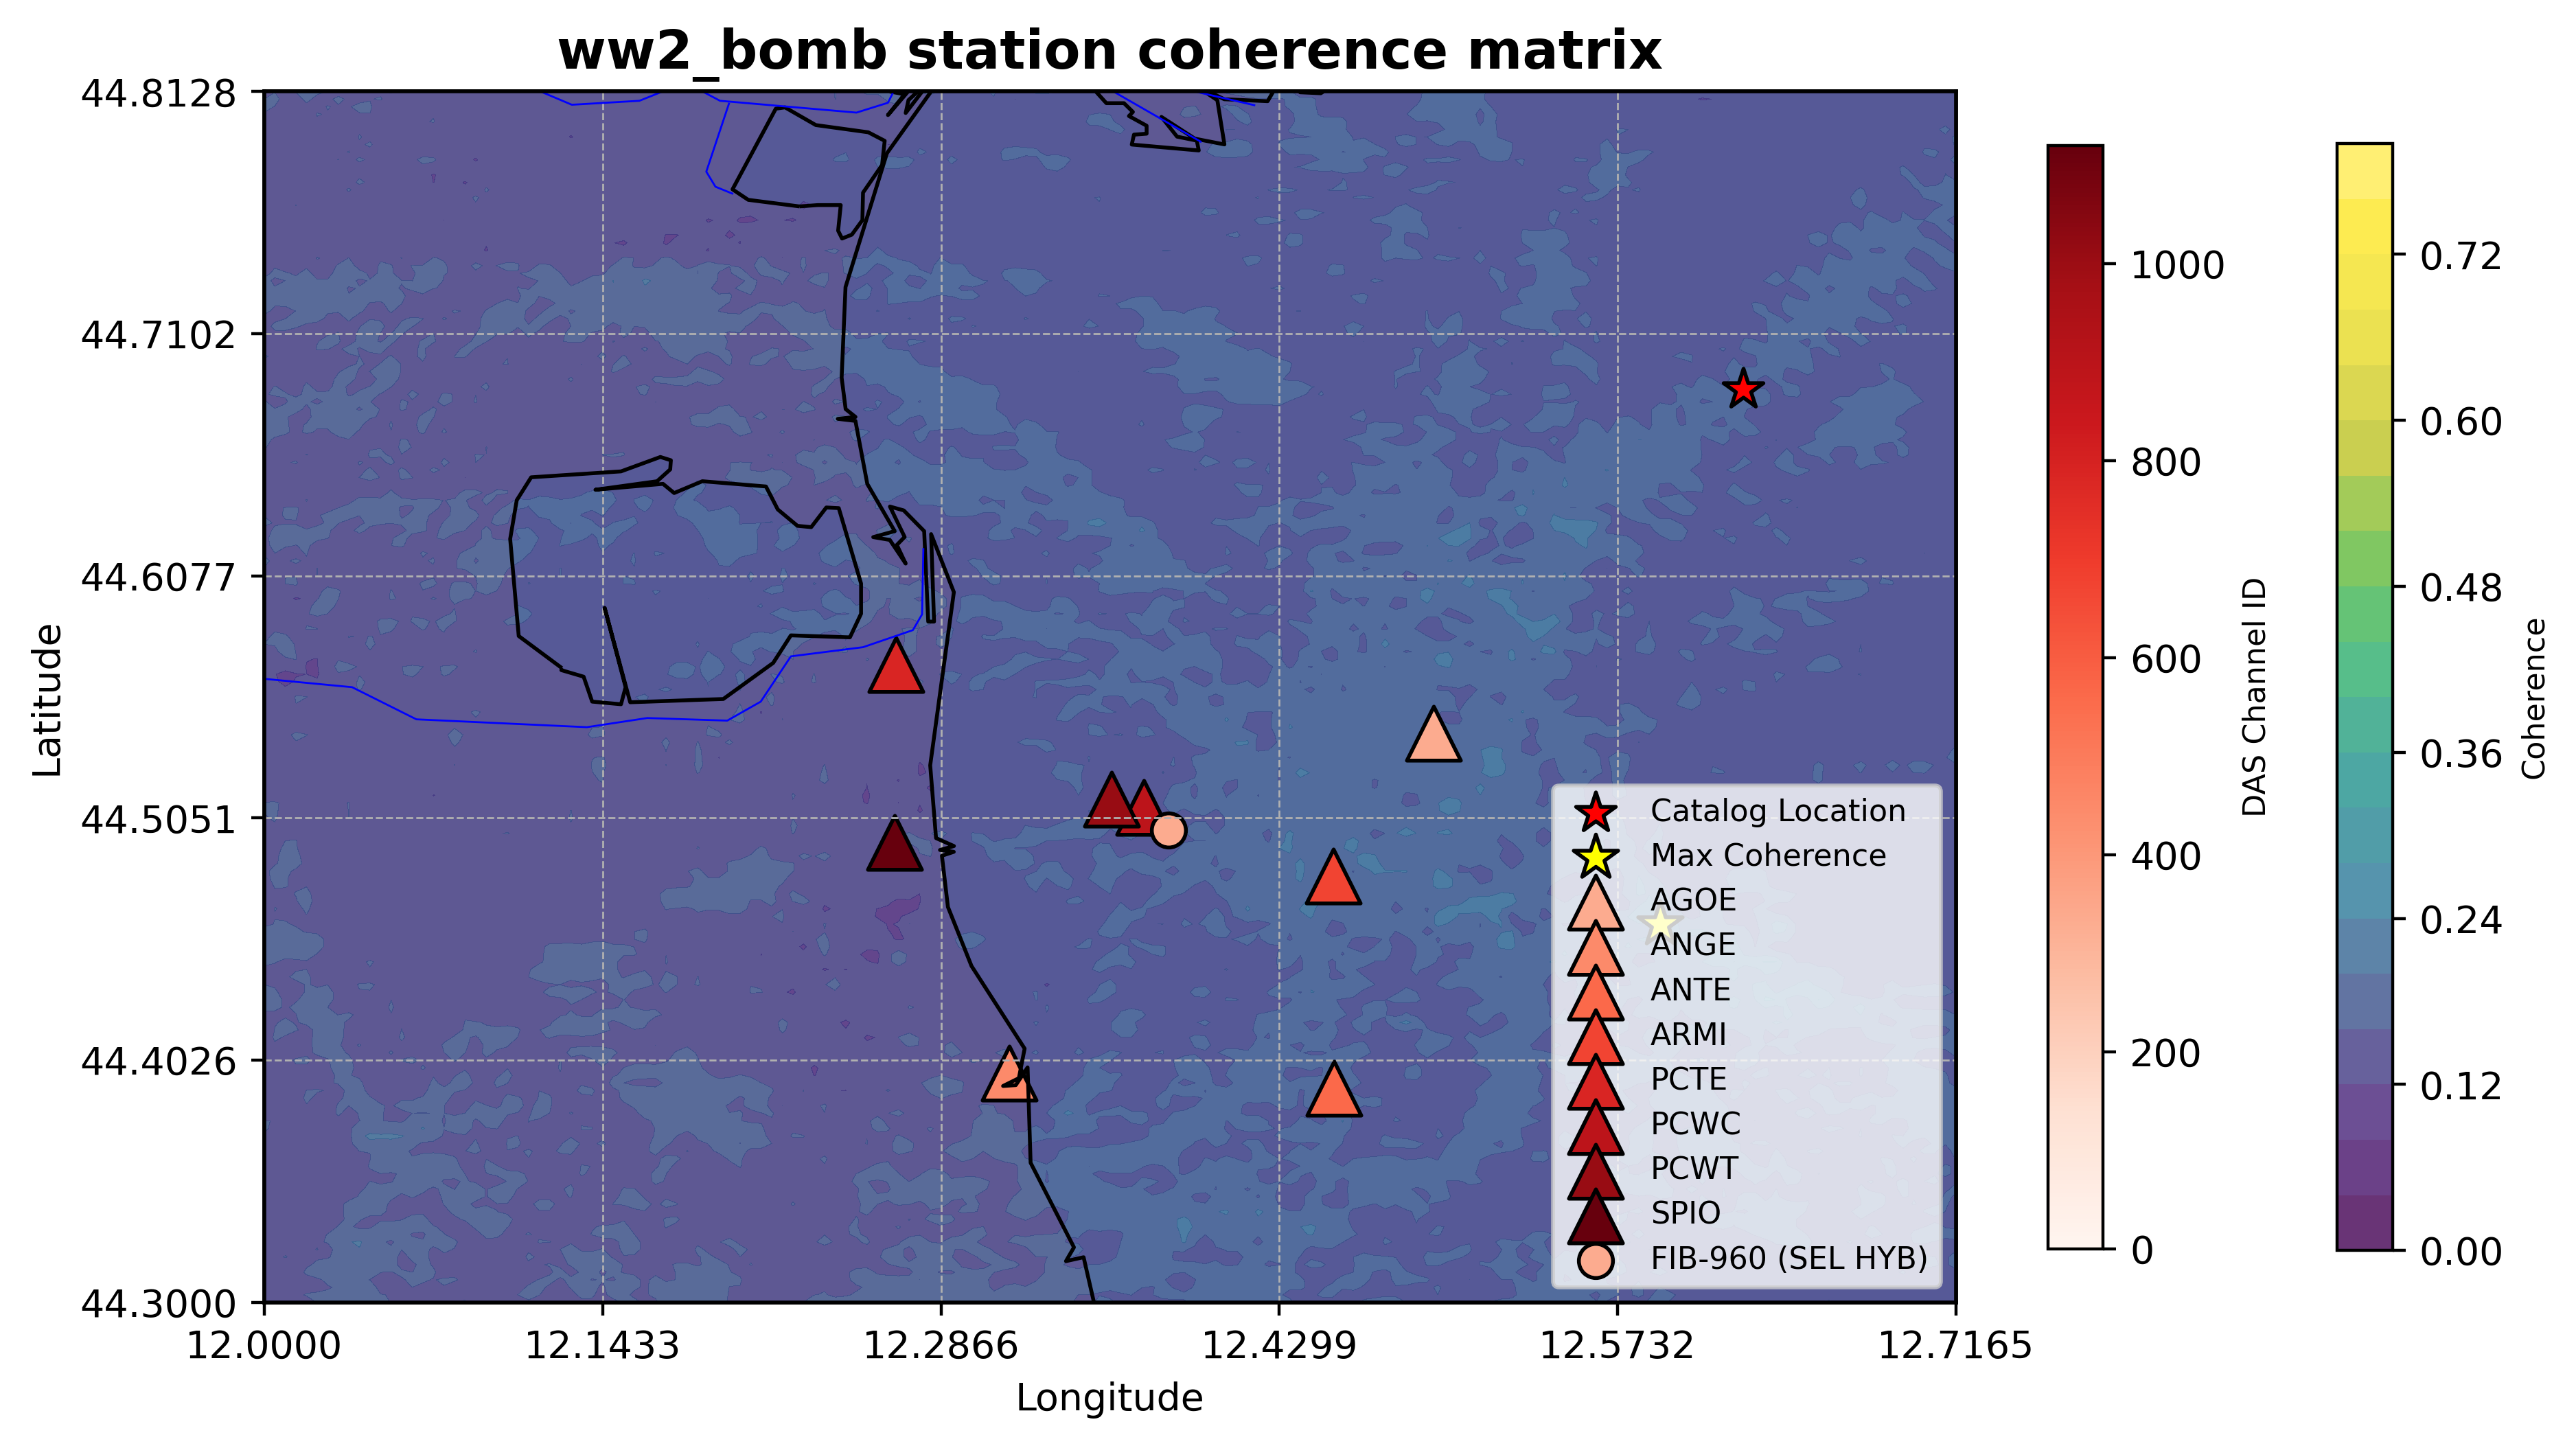

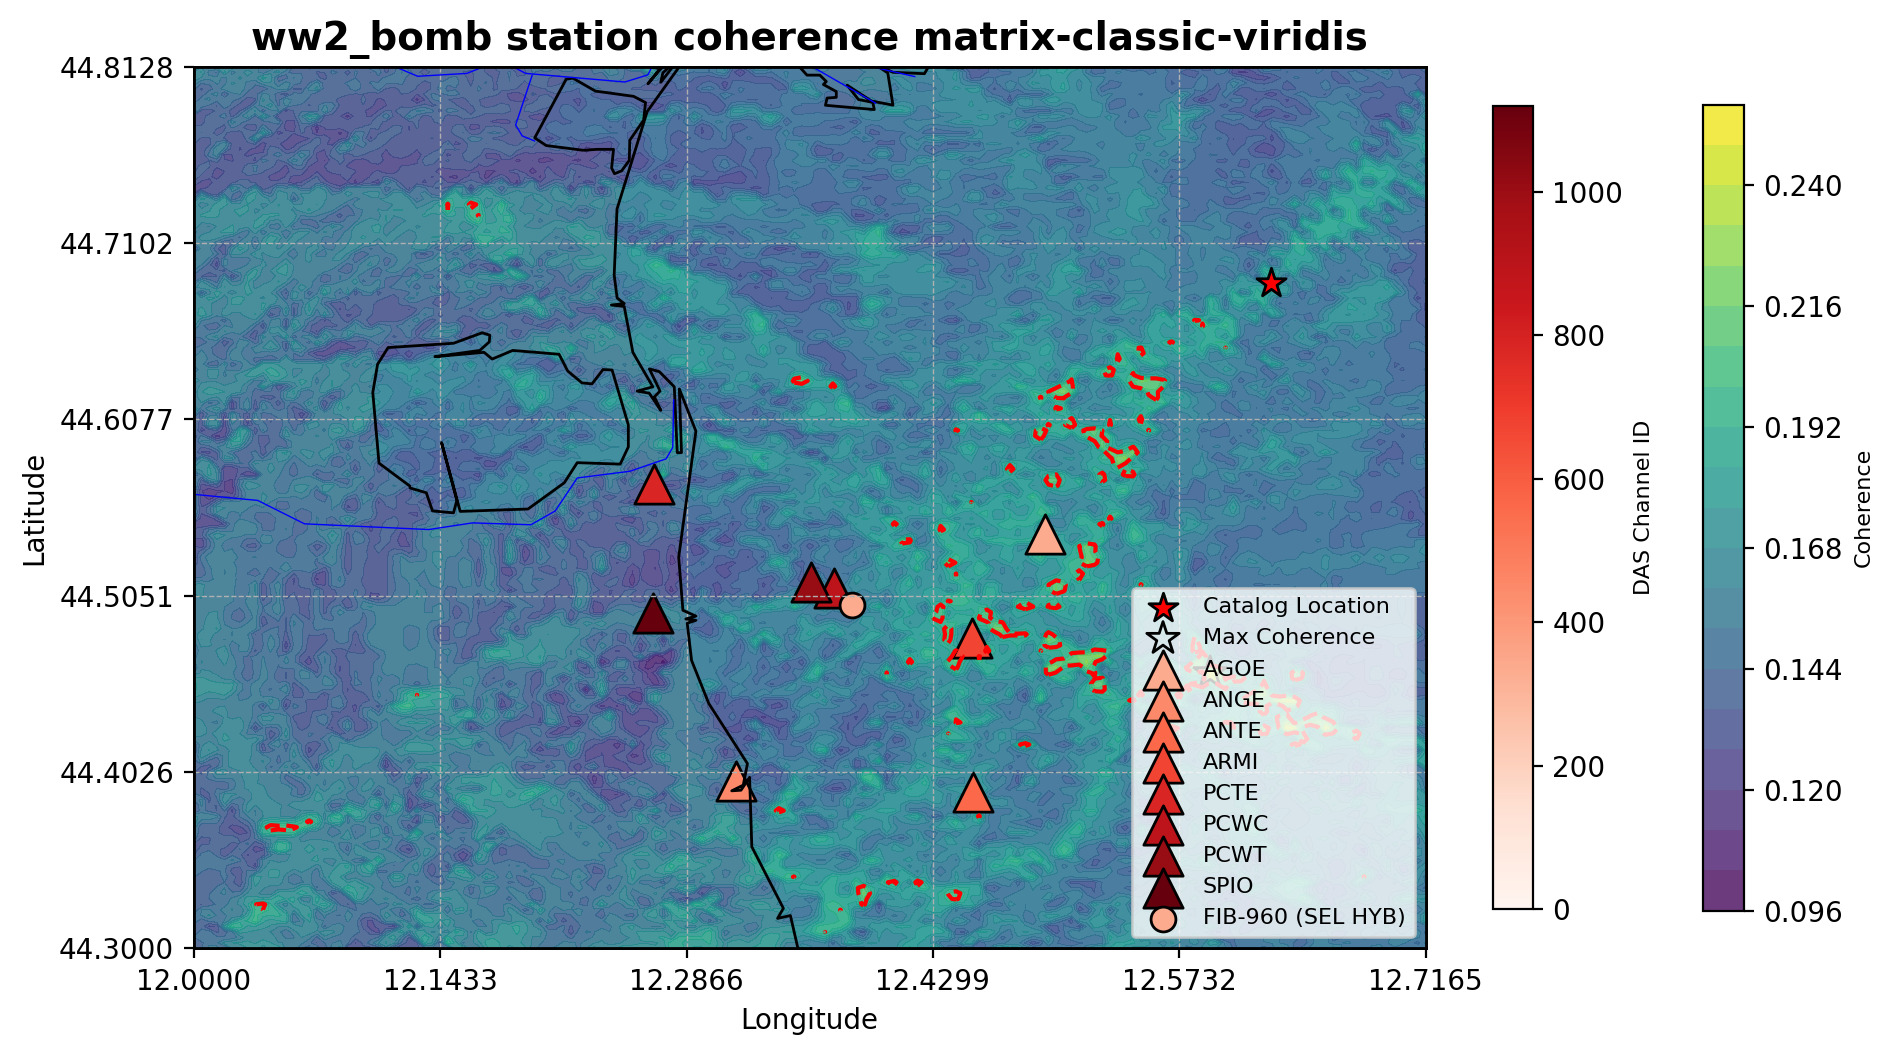

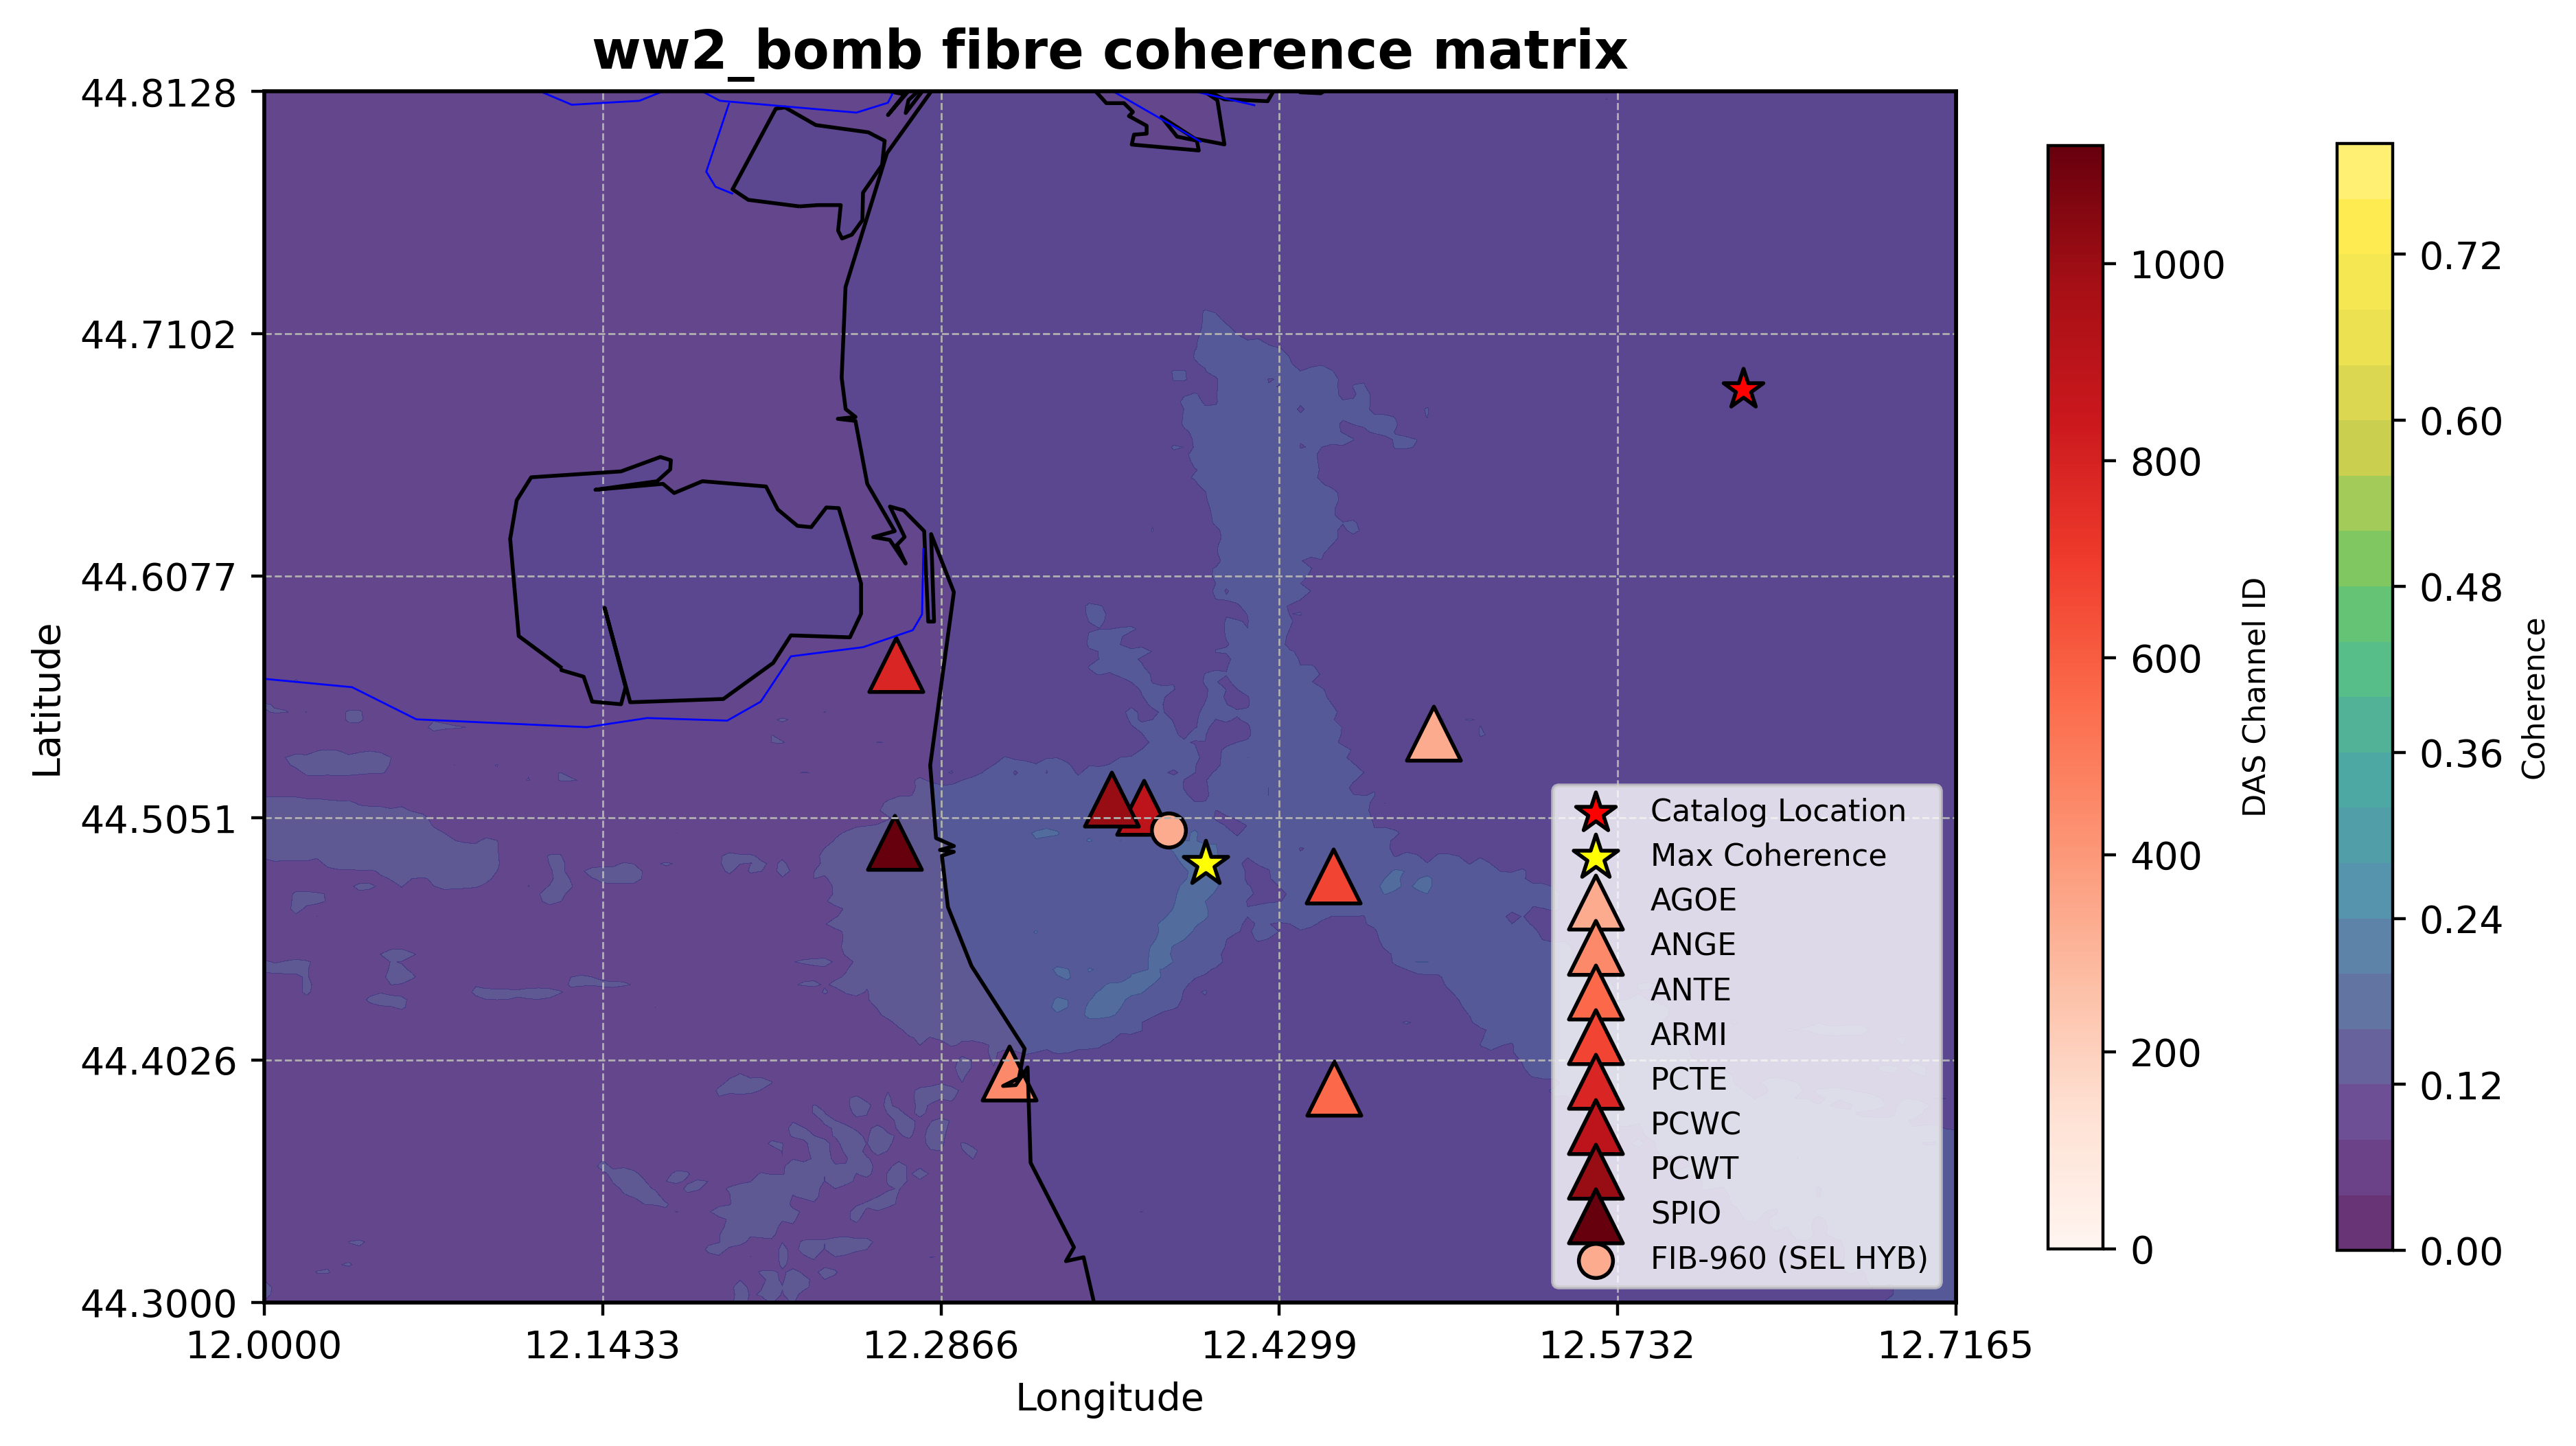

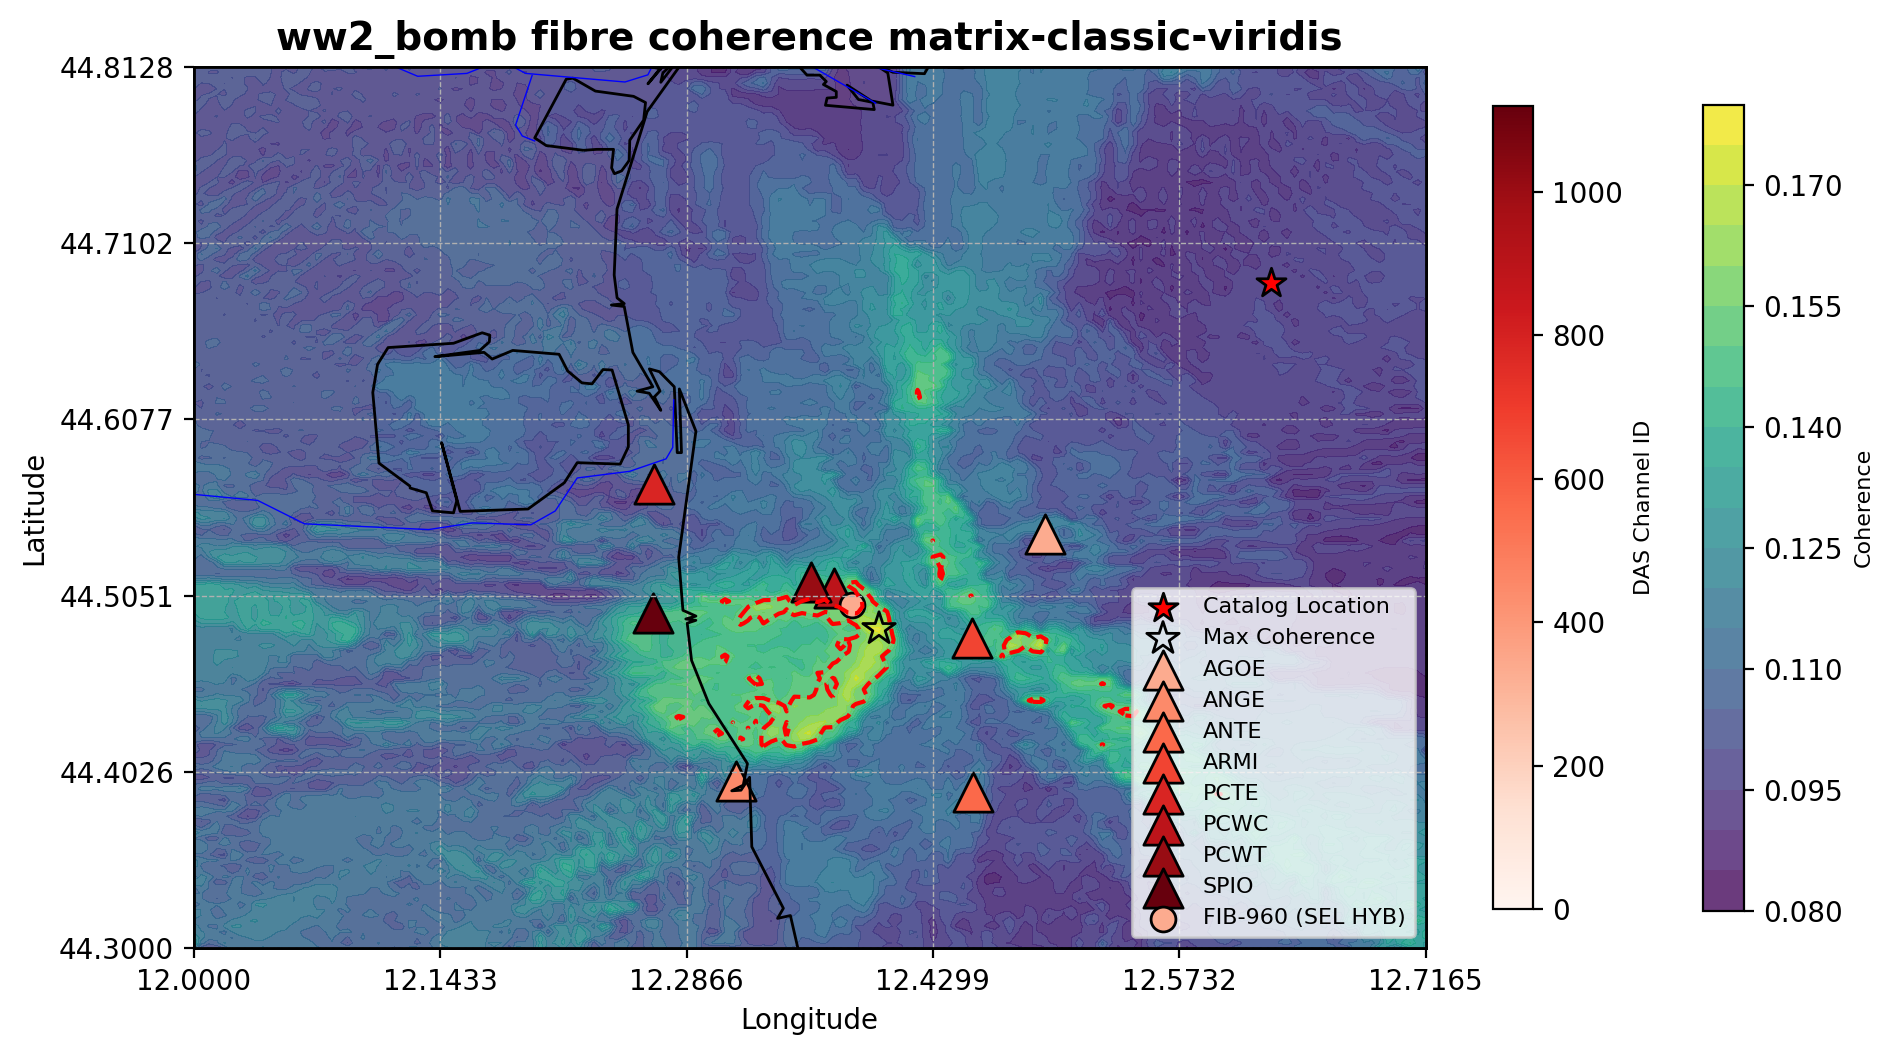

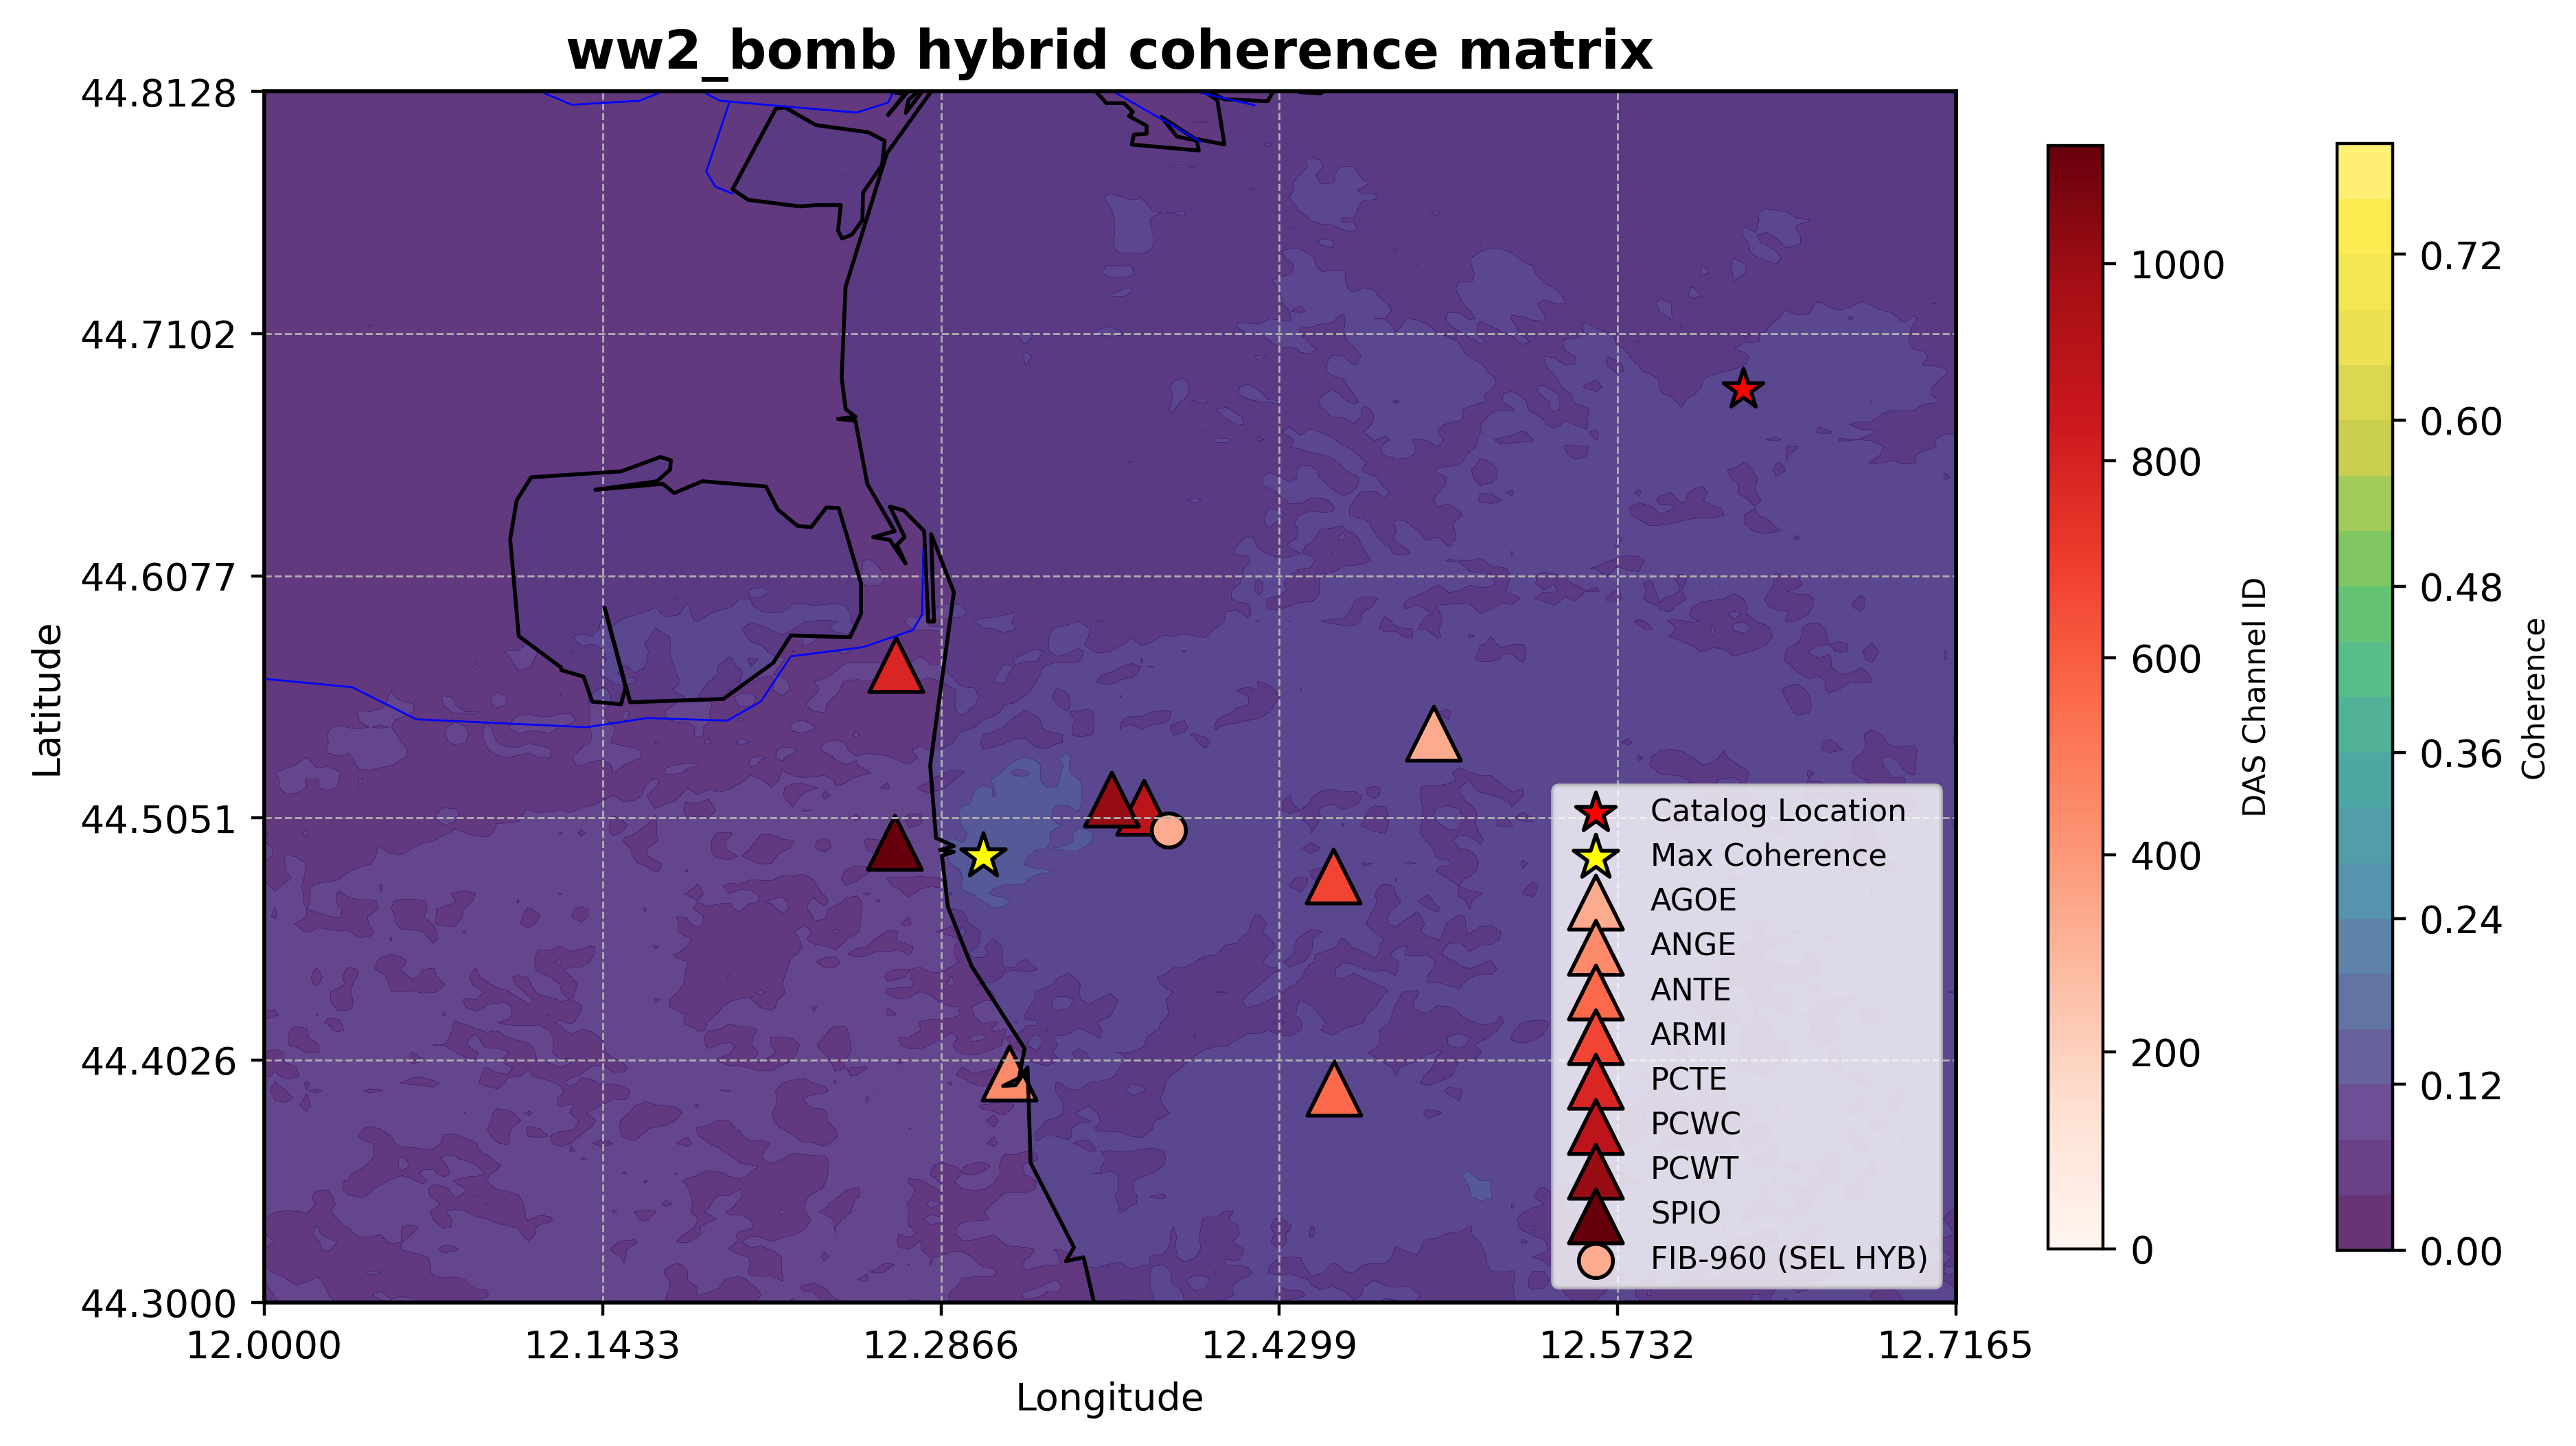

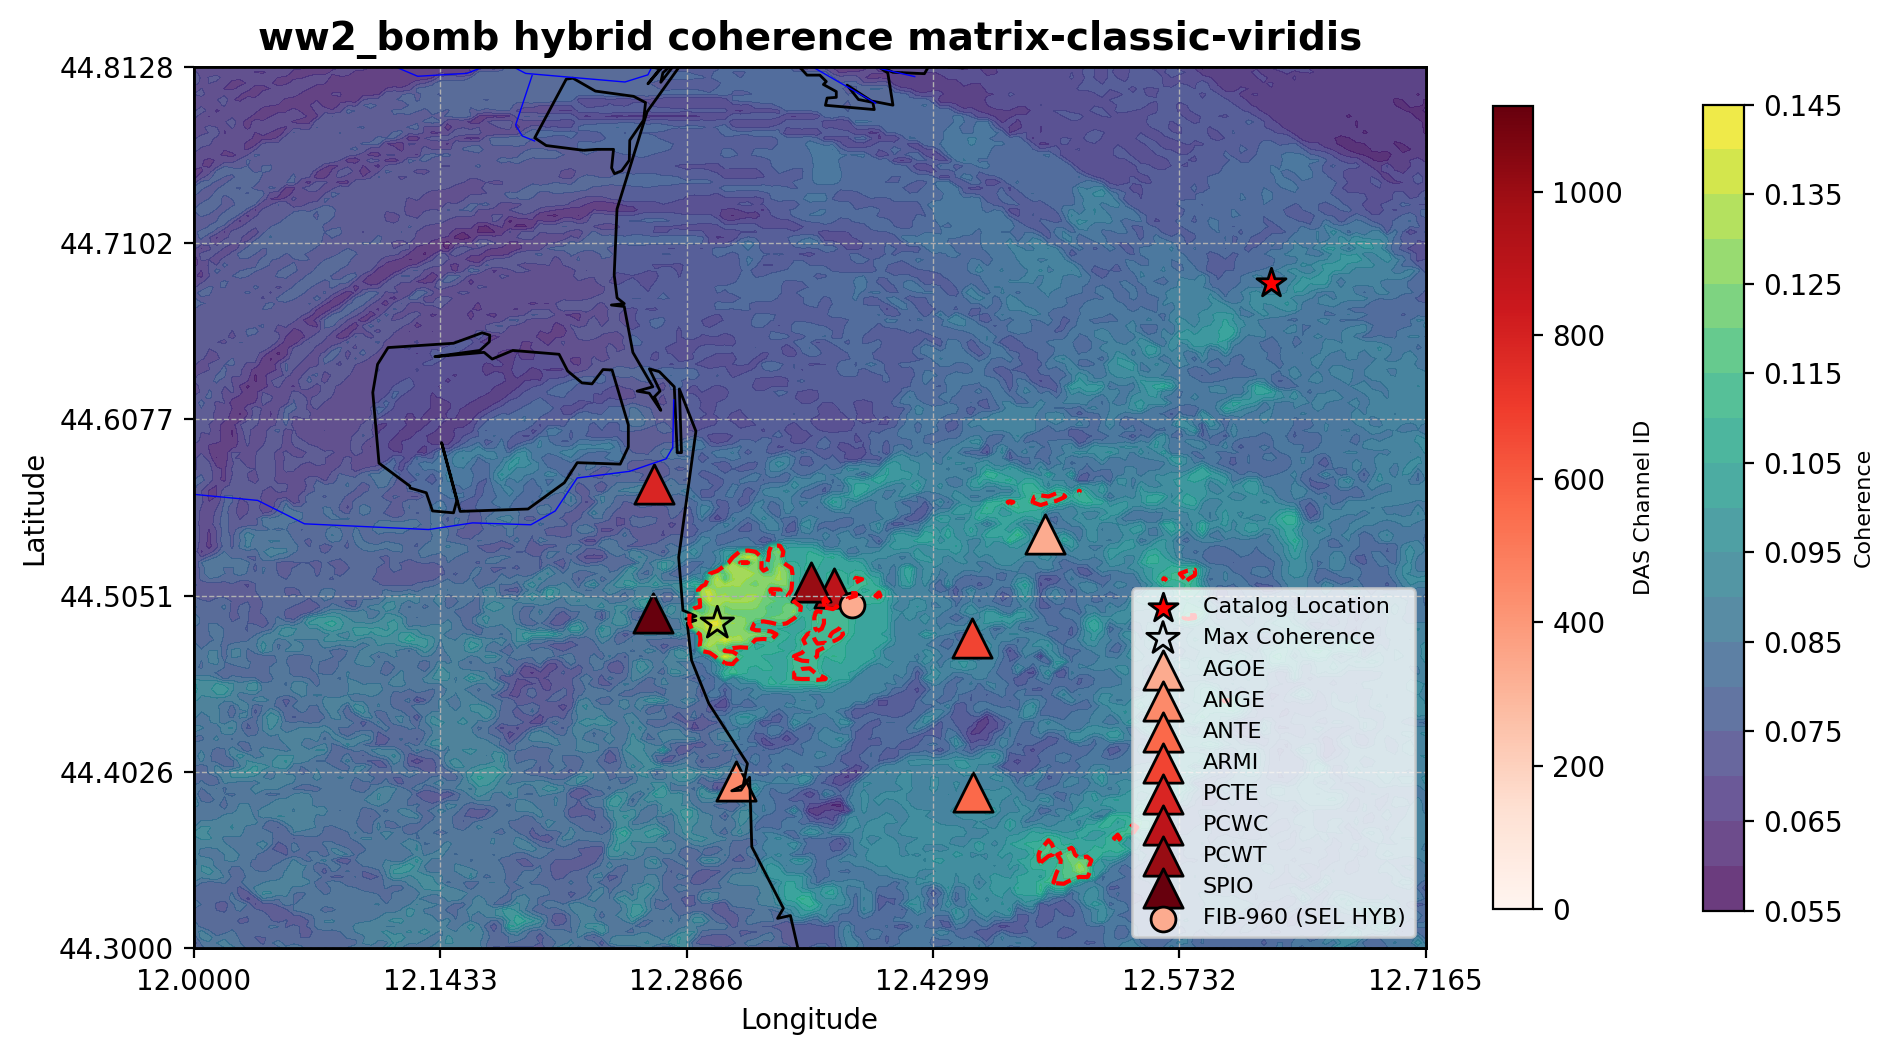

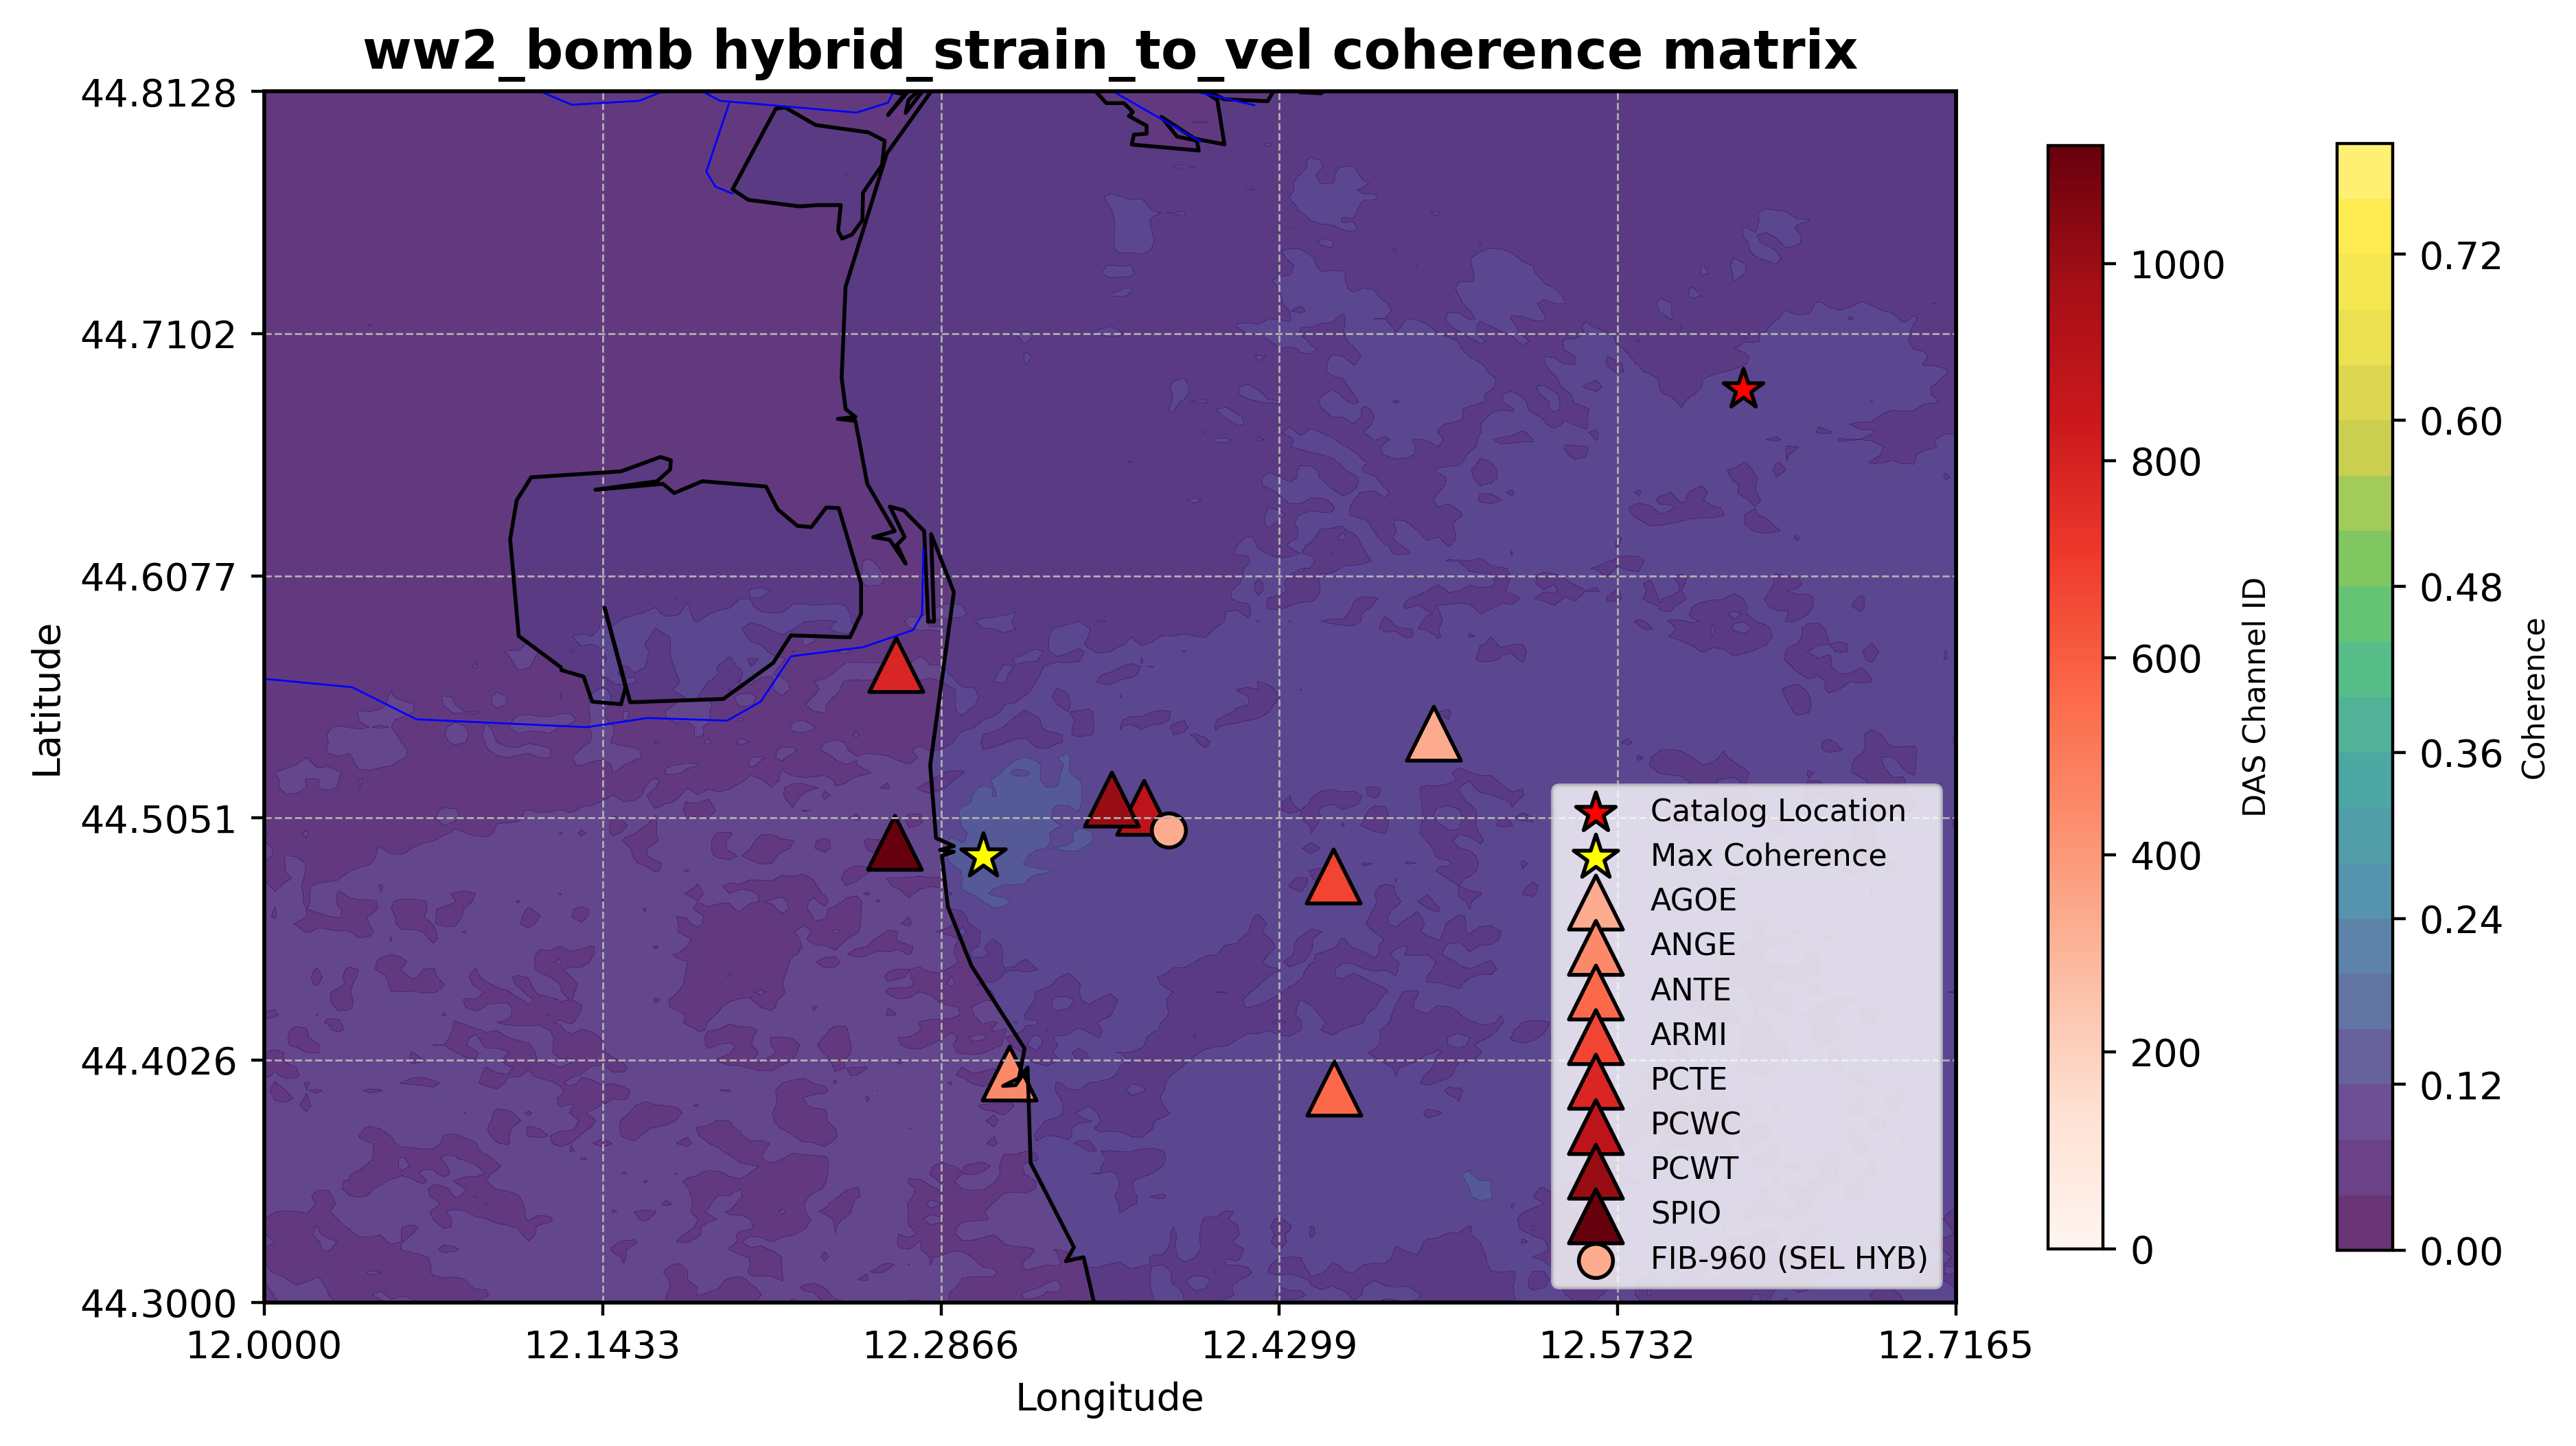

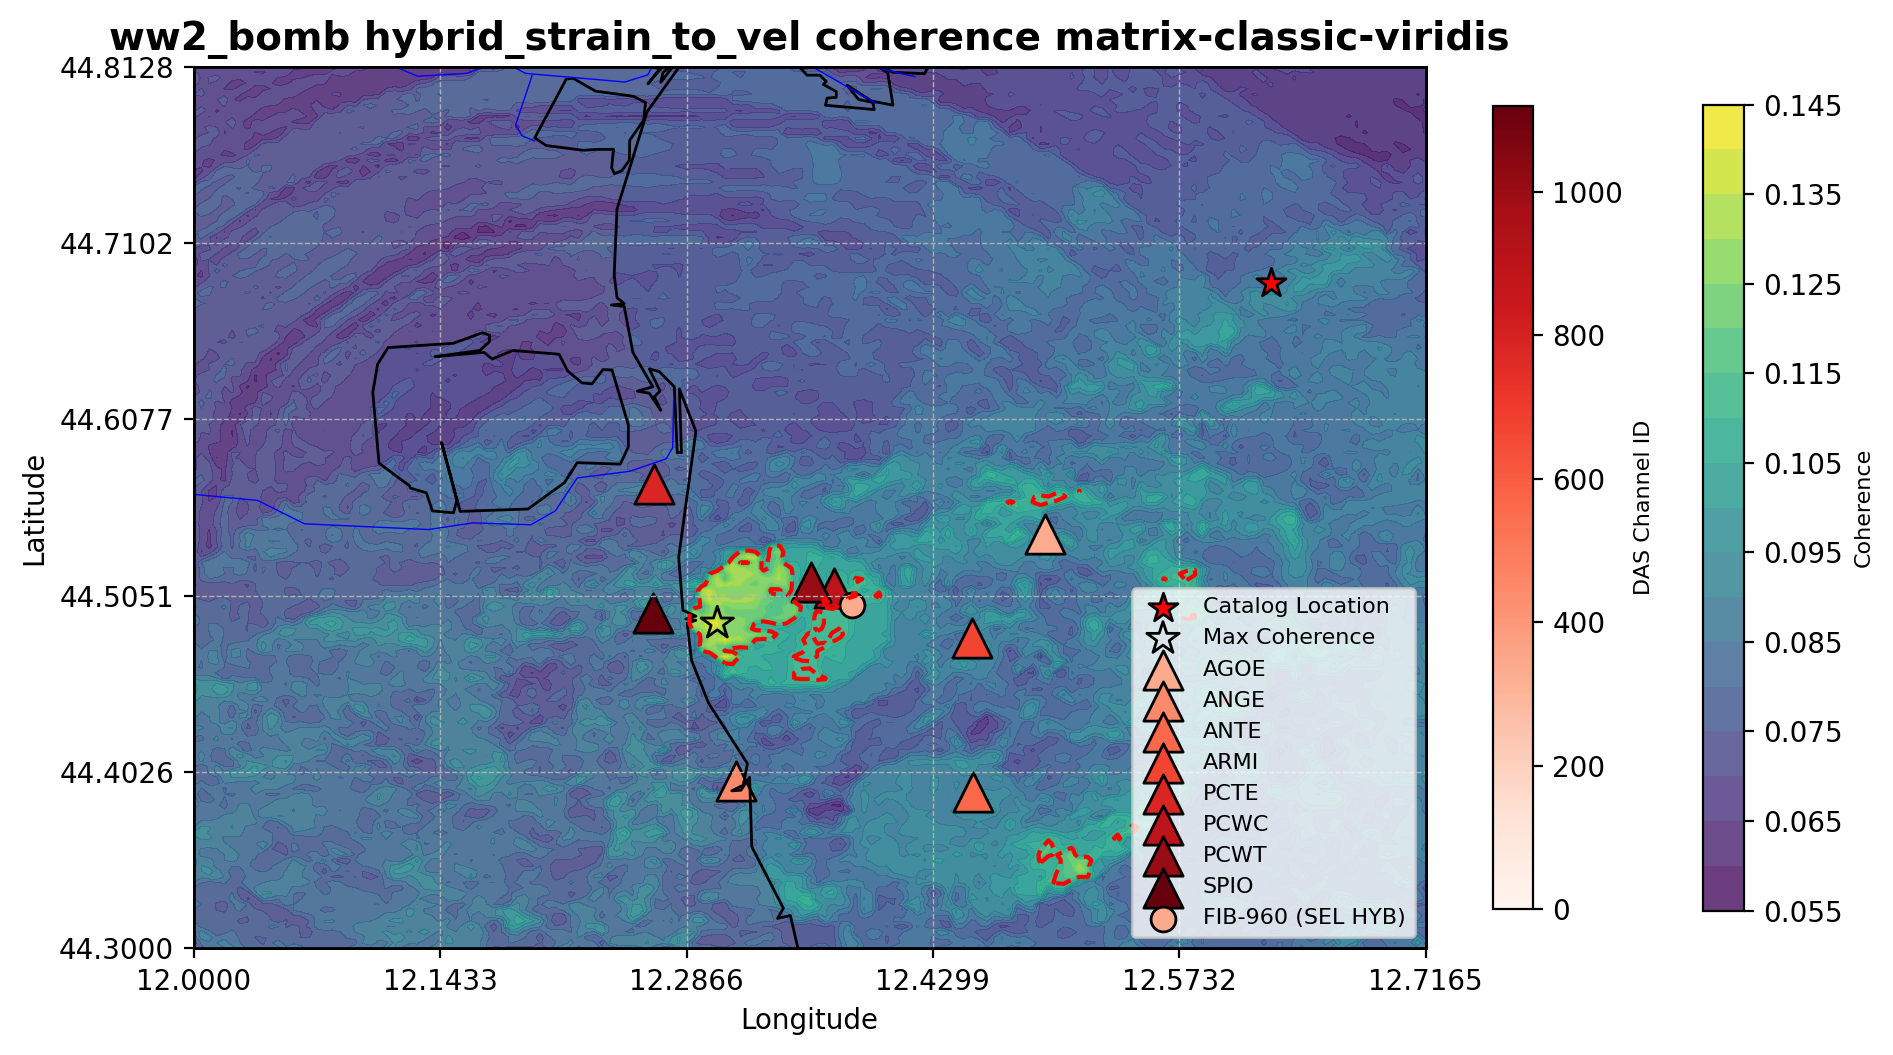

In [30]:
stations = {
    "AGOE": (44.5409, 12.4951),
    "ANGE": (44.3972, 12.3156),
    "ANTE": (44.3908, 12.4531),
    "ARMI": (44.4806, 12.4528),
    "PCTE": (44.5700, 12.2677),
    "PCWC":  (44.5097, 12.3724),
    "PCWT":  (44.5131, 12.3589), 
    "SPIO":  (44.4949, 12.2671)
}

#das_hyb = {
#
#    "FIB-070 (SEL HYB)": (44.5083, 12.3730),
#    "FIB-270 (SEL HYB)": (44.5063, 12.3749),
#    "FIB-420 (SEL HYB)": (44.5046, 12.3770),
#    "FIB-730 (SEL HYB)": (44.5012, 12.3813) ,
#    "FIB-870 (SEL HYB)": (44.5002, 12.3825),
#    "FIB-960 (SEL HYB)": (44.4999, 12.3829)
#}

das_hyb = {
    "FIB-960 (SEL HYB)": (44.4999, 12.3829)
}

base_dir = "/home/emanuele/data/emanuele/loki-das/ravenna/events"

geometry_das = "/home/emanuele/data/emanuele/loki-das/Traveltimes/ravenna/stations_ravenna_total_geom.dat"

ref_lat = 44.30
ref_lon = 12.00

# Define name

name = 'ww2_bomb'


earthquake_location = (44.6868,12.6265, 0)   #qalpq


nx = 161 
ny = 161
nz = 21
dx = 0.5
dz = 0.5



# Earthquake location

earthquake_x, earthquake_y = convert_to_cartesian(earthquake_location[0], earthquake_location[1]  , ref_lat, ref_lon)
earthquake_z = earthquake_location[2] # Example depth in km


files, titles, lat_range, lon_range = load_and_reshape_matrix(name, base_dir, ref_lat=ref_lat, ref_lon=ref_lon, dx=dx, dz=dz, nx=nx, ny=ny, nz=nz)

print(files)
for i in range(4):
    corrmatrix_sta = np.load(files[i])
    corrmatrix_sta = np.reshape(corrmatrix_sta, (nx, ny, nz))
    cartesian_grid_x, cartesian_grid_y= np.meshgrid(np.linspace(0, 75.5, nx), np.linspace(0,75.5, ny))


    #plot_geographical_map_simple(
    #    ref_lat, ref_lon, stations, geometry_das, earthquake_location, corrmatrix_sta,
    #    cartesian_grid_x, cartesian_grid_y, lat_range, lon_range,
    #    title='Integrated seismic network', files=files[0], titles='Integrated seismic network'
    #)
    plot_geographical_map(ref_lat, ref_lon, stations, geometry_das, das_hyb, earthquake_location, corrmatrix_sta,
                    cartesian_grid_x, cartesian_grid_y, lat_range, lon_range,
                    title=titles[i], files=files[i], titles = titles[i], clip = 0.8)
    
    plot_geographical_map_notnorm(ref_lat, ref_lon, stations, geometry_das, das_hyb, earthquake_location, corrmatrix_sta,
                    cartesian_grid_x, cartesian_grid_y, lat_range, lon_range,
                    title=titles[i] + '-classic-viridis', files=files[i], titles = titles[i], clip = 0.8)
    
    #plot_xz_yz_sections(corrmatrix_sta, cartesian_grid_x, cartesian_grid_z, cartesian_grid_y, cmap, norm)
    
    #load_das_channels(geometry_das)   
    



## 3D PLOTS 

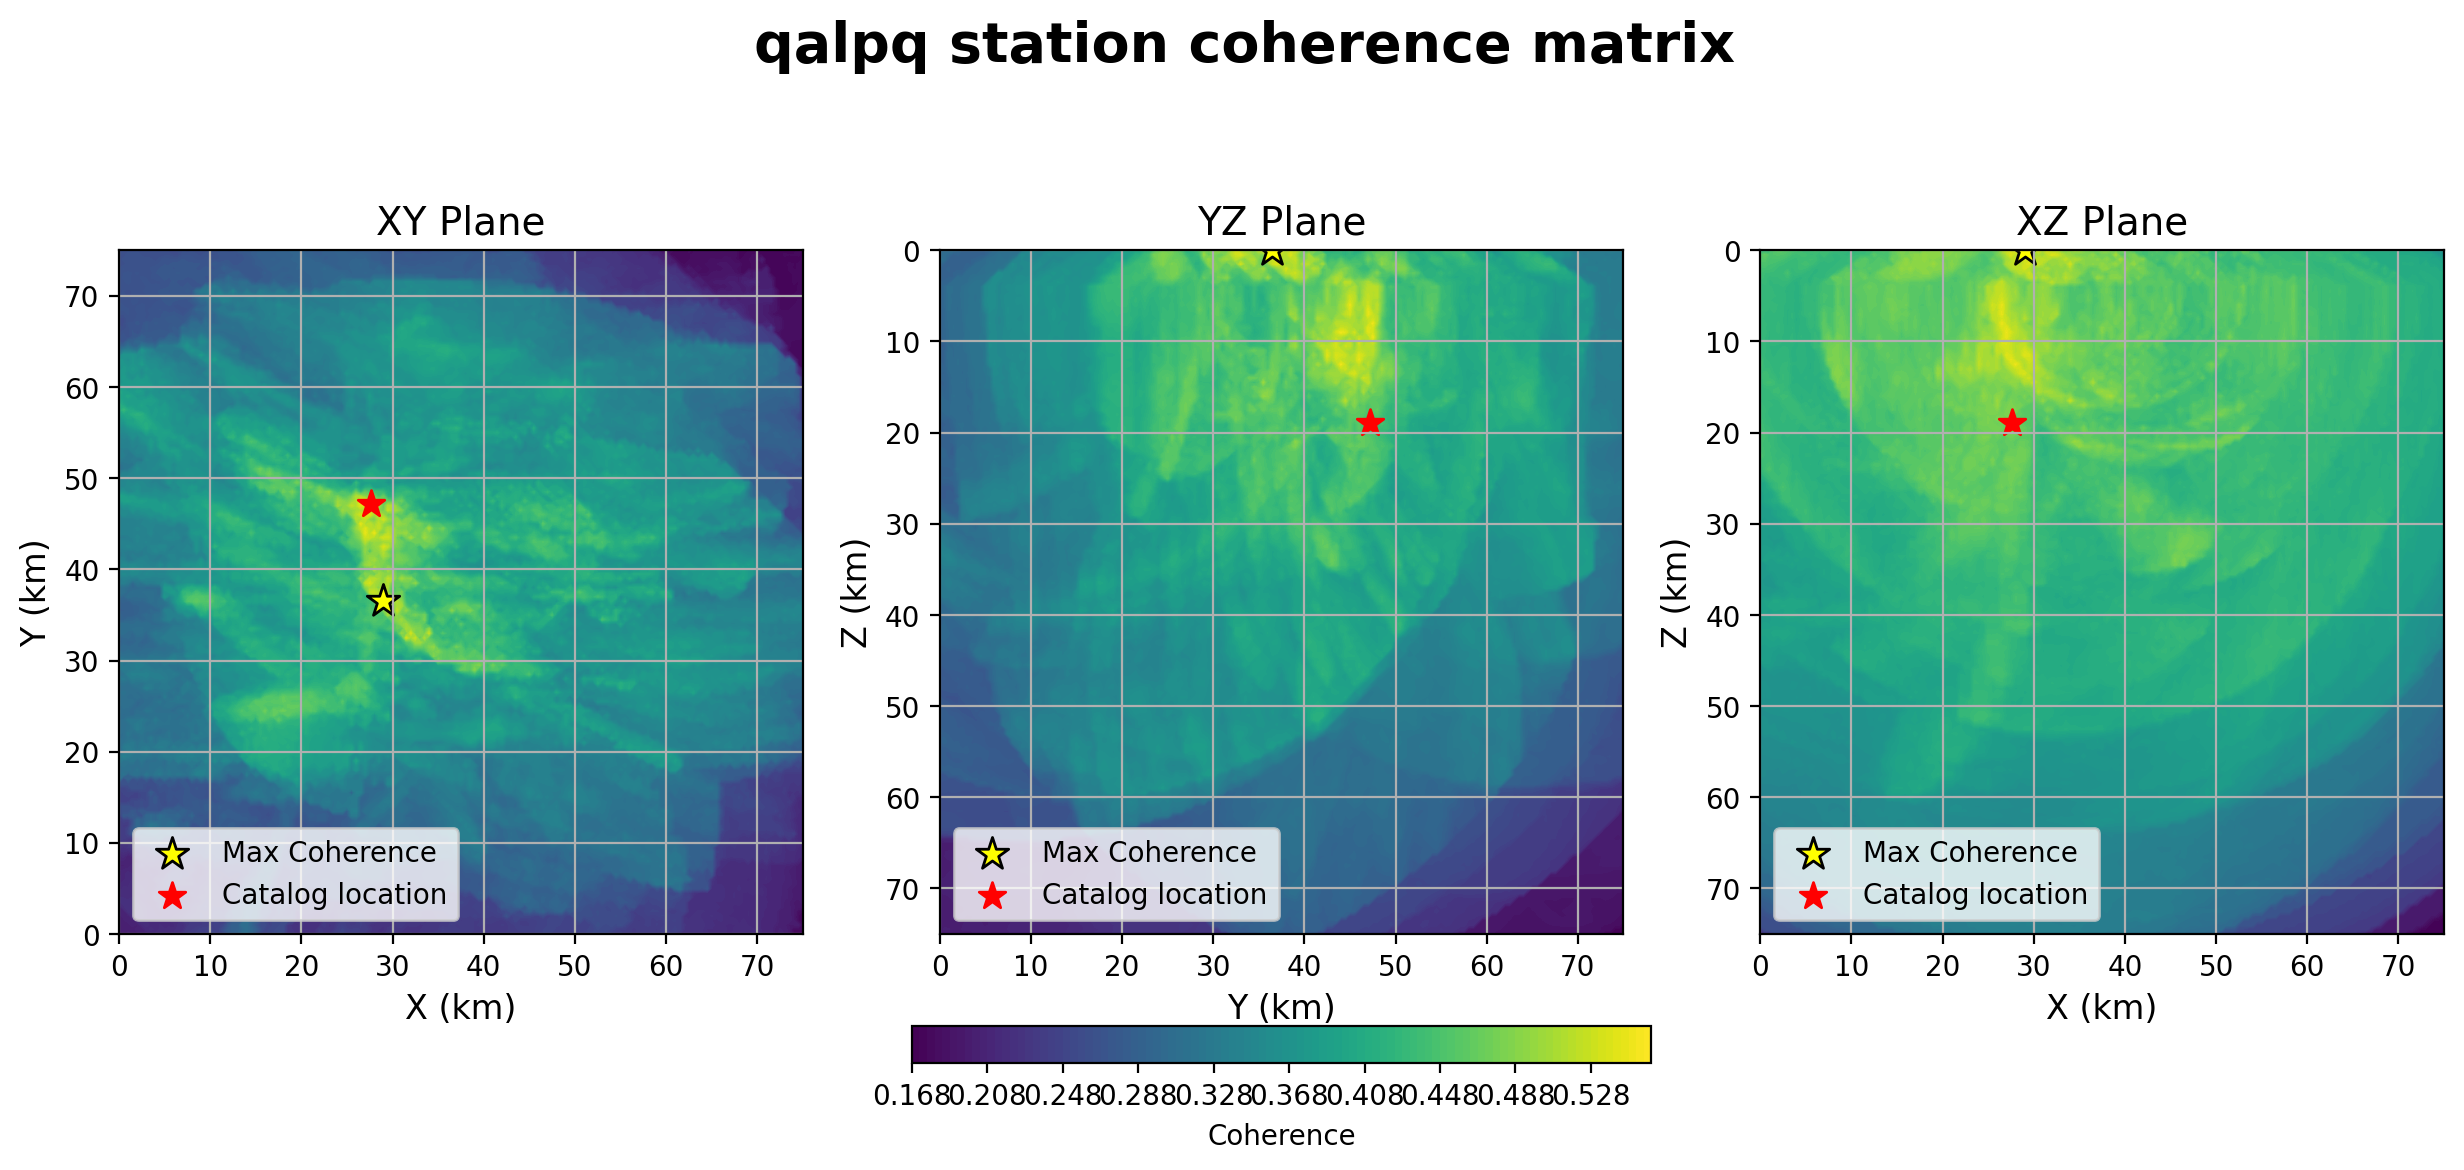

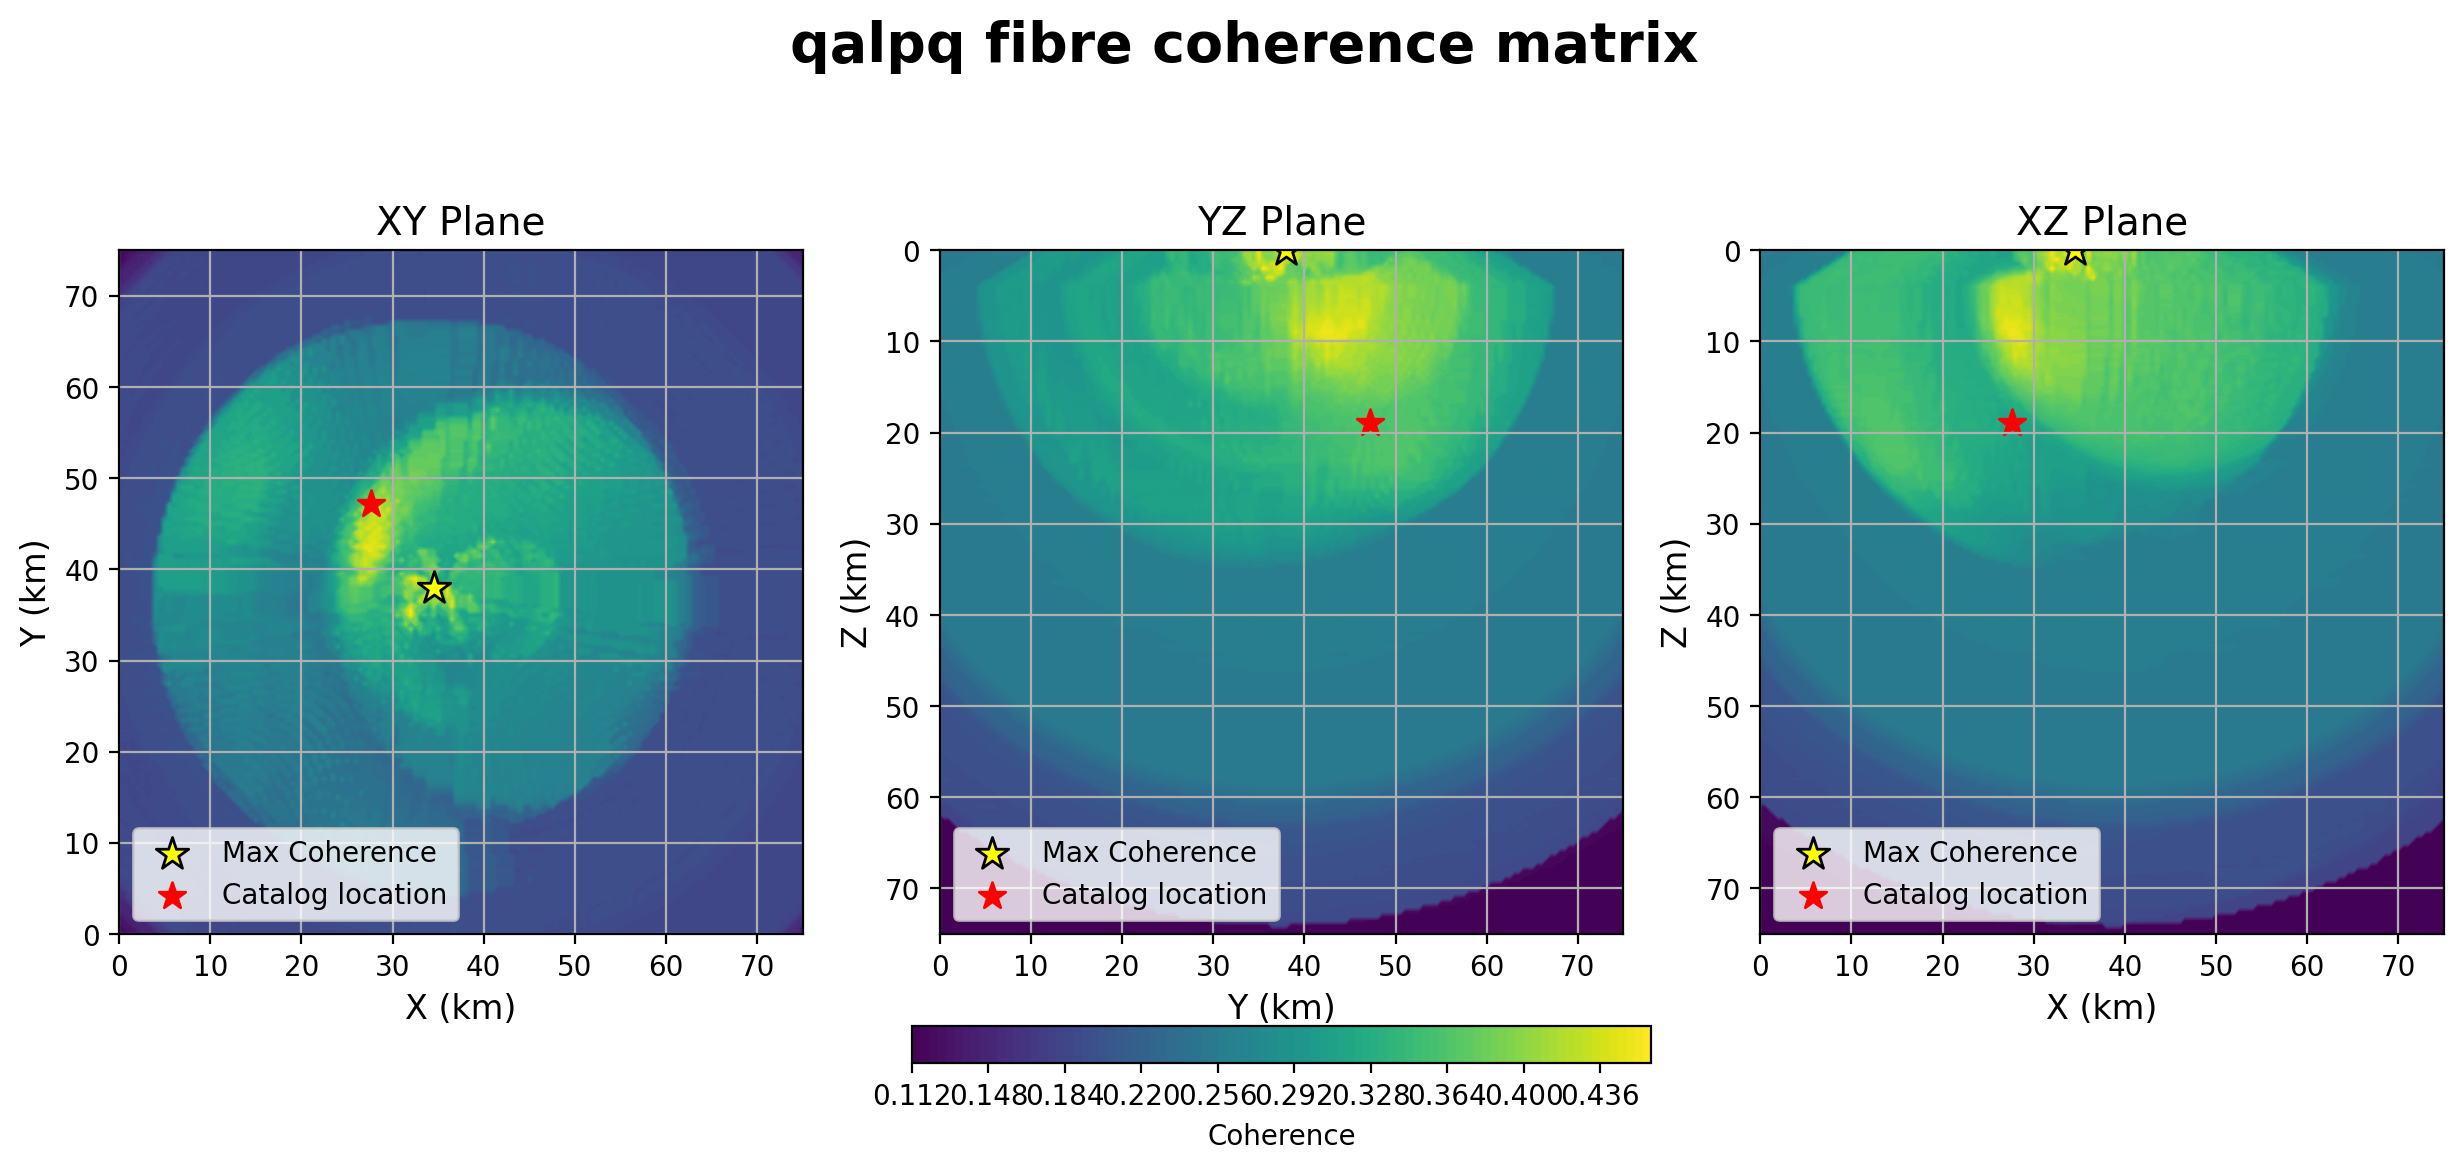

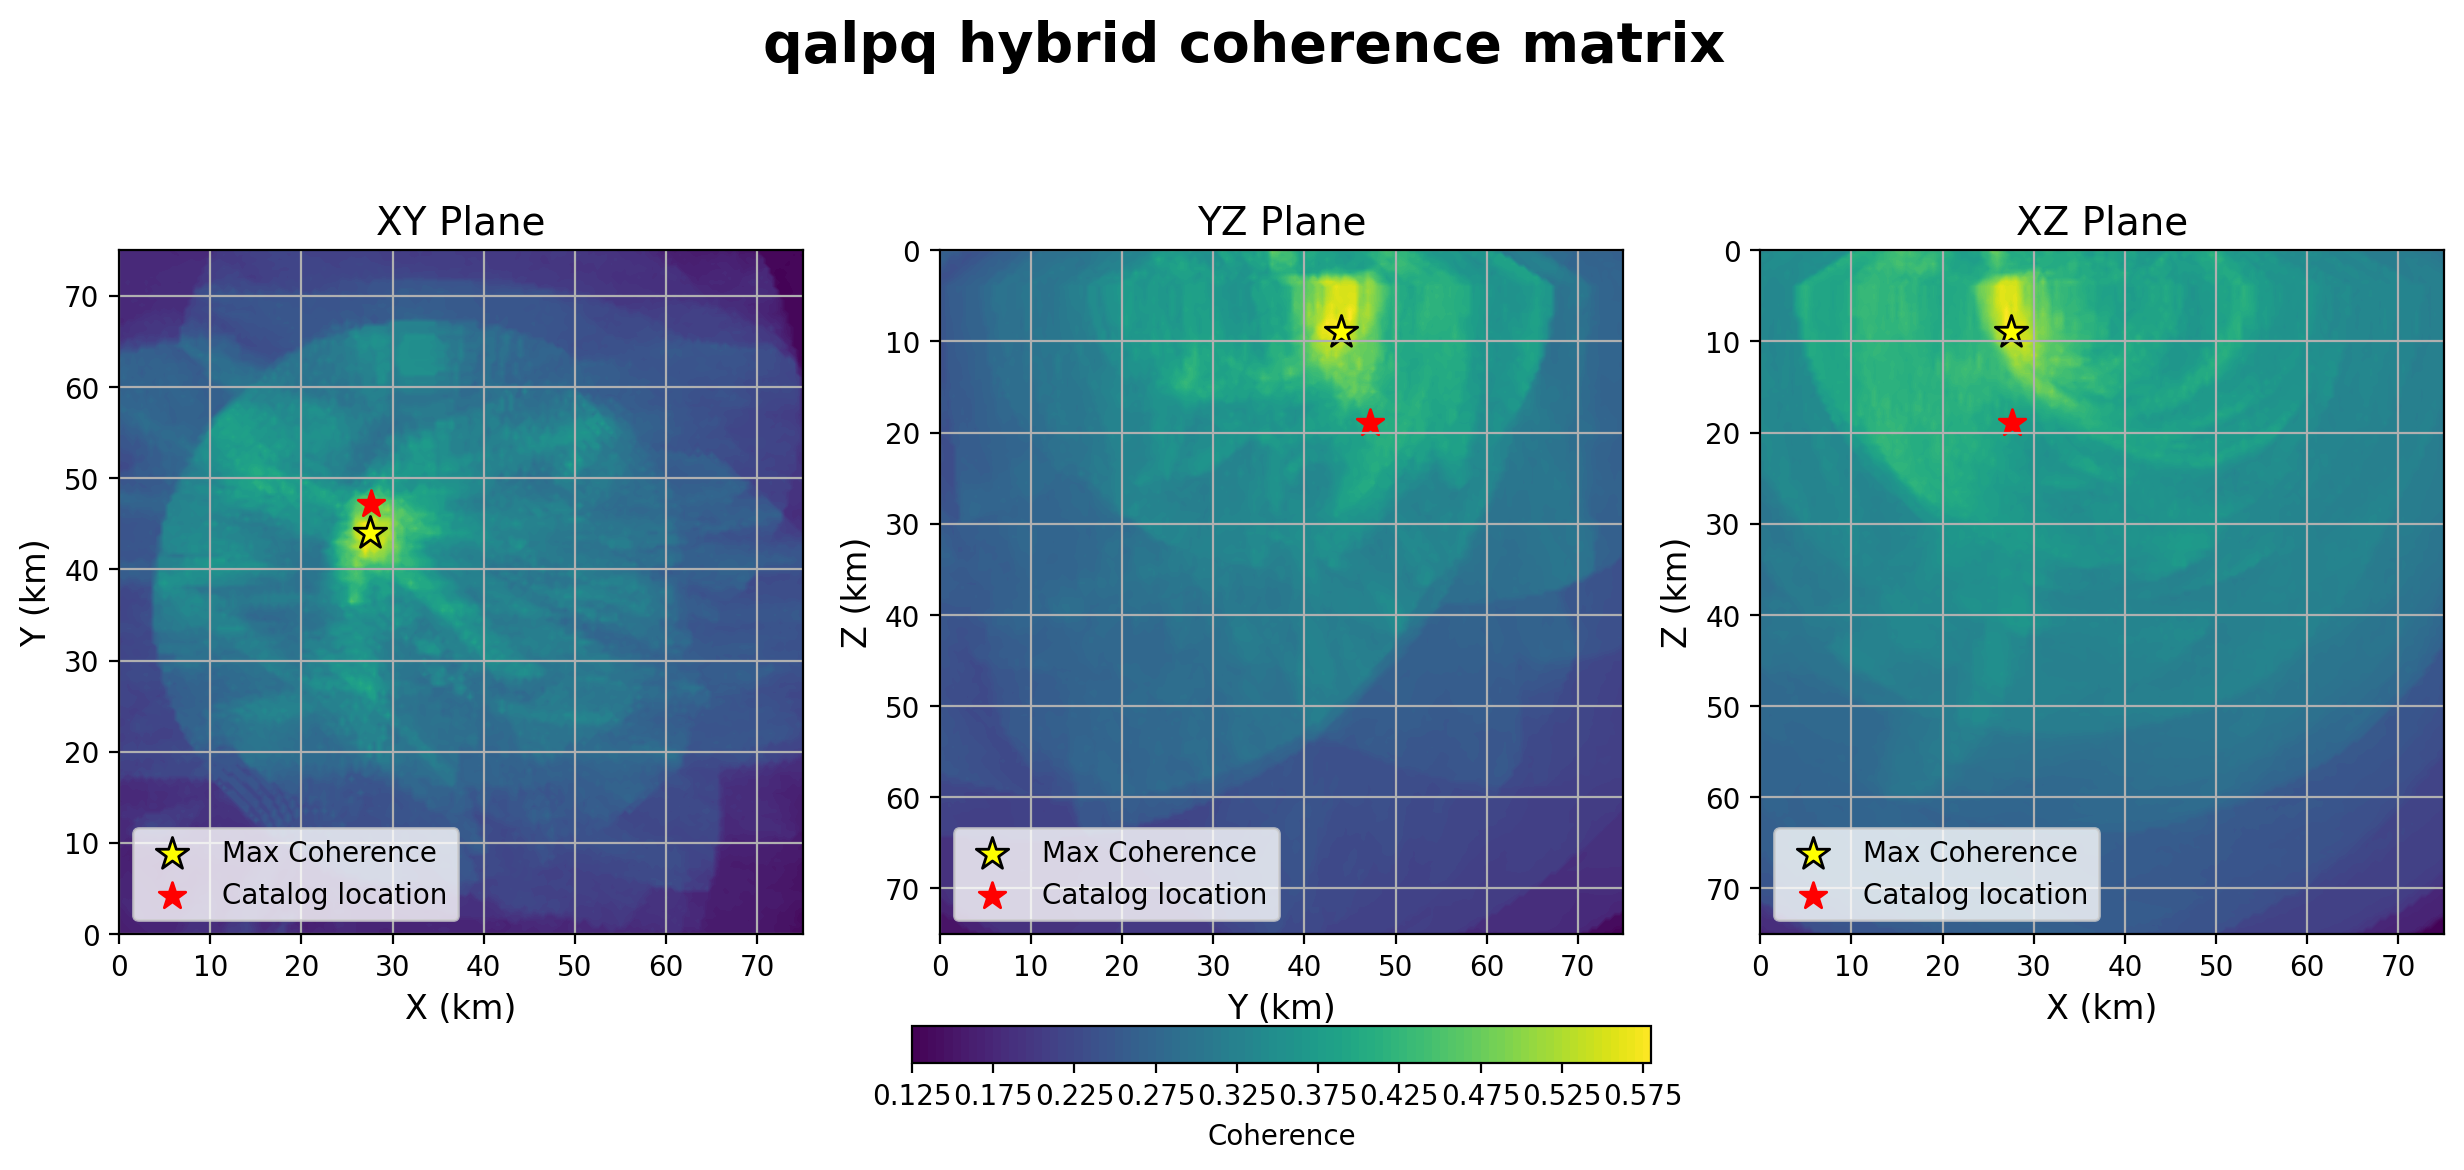

In [9]:
dx = 0.5
dz = 0.5

x =  np.arange(0, (nx * dx) , (dx))  #define the grid search based on the 2D traveltime grid
y =  np.arange(0, (nx * dx), (dx ))  #define the grid search based on the 2D traveltime grid
z =  np.arange(0, (nz * dz), dz) #define the grid search based on the 2D traveltime grid

for i in range(3):
    corrmatrix_sta = np.load(files[i])
    corrmatrix_sta = np.reshape(corrmatrix_sta, (nx, ny, nz))
    coherence_plot_3d(corrmatrix_sta, files=files[i], title= titles[i], xax = x, yax = y, zax = z, itrial=1, earthquake_x = earthquake_x  , earthquake_y=earthquake_y  , earthquake_z = 19, clip = 1)